# Group Component 1

--- start ---

# change of data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('./dataA.csv',index_col='index')
df.head()

,PlayerID,PlayerName,FullName,PhotoURL,PlayerURL,Country,Age,Rating in Scale 100,Potential in Scale 100,CurrentClub,...,AttackingWorkRate,DefensiveWorkRate,InternationalReputation,Pace,Shooting,Passing,Dribbling.1,Defending,Physical,PopularityHits
index,,,,,,,,,,,,,,,,,,,,,
0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,FC Barcelona,...,Medium,Low,5,85,92.0,91,95,38,65,771.0
1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,Juventus,...,High,Low,5,89,93.0,81,89,35,77,562.0
2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,Atlético Madrid,...,Medium,Medium,3,87,92.0,78,90,52,90,150.0
3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,Manchester City,...,High,High,4,76,86.0,93,88,64,78,207.0
4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,Paris Saint-Germain,...,High,Medium,5,91,85.0,86,94,36,59,595.0


In [3]:
# changing target into pure numeric
def convert_value(value):
    if value == '0':
        return 0
    v = float(value[:-1])
    if value[-1].lower() == 'm':
        return v * 1000000
    elif value[-1].lower() == 'k':
        return v * 1000
    return value  


df.iloc[:, 19] = df.iloc[:, 19].apply(convert_value) # MarketValue
df['MarketValue'] = pd.to_numeric(df['MarketValue'])

In [4]:
# unify unit into SI
not_cm = df[~df["Height"].str.endswith("cm")]
def convert_to_cm(height):
    if height.endswith("cm"):
        return float(height[:-2]) 
    elif "'" in height:
        feet, inches = height.split("'")  
        feet = float(feet.strip())  
        inches = float(inches.replace('"', '').strip()) 
        return (feet * 30.48) + (inches * 2.54)  
    else:
        return None  


df["Height"] = df["Height"].apply(convert_to_cm)
not_kg = df[~df["Weight"].str.endswith("kg")]
def convert_to_kg(weight):
    if weight.endswith("kg"):
        return float(weight[:-2]) 
    # 如果以 "lbs" 结尾，进行转换
    elif weight.endswith("lbs"):
        return float(weight[:-3]) * 0.453592 
    else:
        return None  
df["Weight"] = df["Weight"].apply(convert_to_kg)

## trying to create bins using default approach, failed

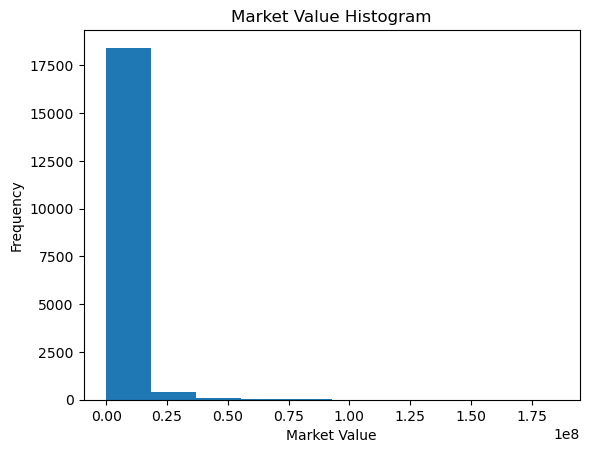

In [5]:
plt.hist(df['MarketValue'], bins=10)  # 10 bins, default
plt.title('Market Value Histogram')
plt.xlabel('Market Value')
plt.ylabel('Frequency')
plt.show()
#very imbalance, need to fix

## As we can see, if we create bins by equal dist approch, the imbalance would be too much; fix it with qual freq bins

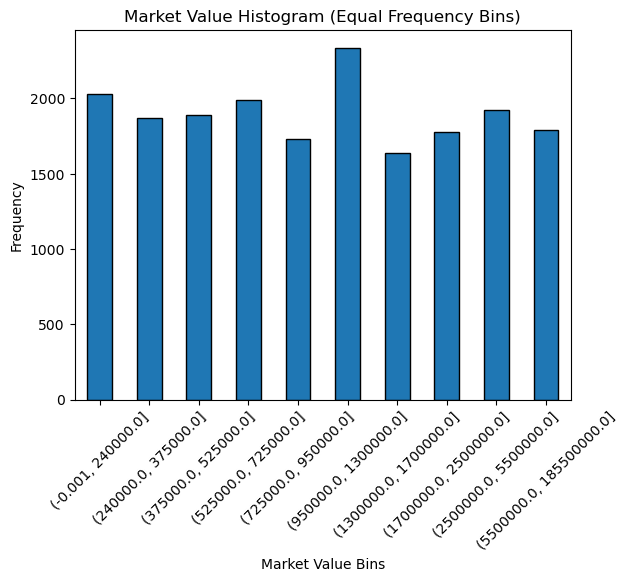

In [6]:
# Use qcut to create equal frequency bins
df['MarketValue_bins'] = pd.qcut(df['MarketValue'], q=10)  # q=10 means dividing data into 10 bins

# Plot the histogram
df['MarketValue_bins'].value_counts().sort_index().plot(kind='bar', edgecolor='black')
plt.title('Market Value Histogram (Equal Frequency Bins)')
plt.xlabel('Market Value Bins')
plt.ylabel('Frequency')
plt.xticks(rotation=45)  # Rotate x-axis labels for better visibility
plt.show()

In [7]:
bin_labels = df['MarketValue_bins'].cat.categories
for i, label in enumerate(bin_labels):
    print(f"Category {i}: {label}")

Category 0: (-0.001, 240000.0]
Category 1: (240000.0, 375000.0]
Category 2: (375000.0, 525000.0]
Category 3: (525000.0, 725000.0]
Category 4: (725000.0, 950000.0]
Category 5: (950000.0, 1300000.0]
Category 6: (1300000.0, 1700000.0]
Category 7: (1700000.0, 2500000.0]
Category 8: (2500000.0, 5500000.0]
Category 9: (5500000.0, 185500000.0]


In [8]:
#save file
#df.to_csv('./classification.csv', encoding='utf-8', index=True)

## data split

In [ ]:
# Assign the target variable 'MarketValue_category_equal_freq' to y
y = df.loc[:, "MarketValue_category_euqal_freq"]

# Drop the target column from the dataset, keeping only features for X
X = df.drop(columns='MarketValue_category_euqal_freq')

# Split the dataset into 90% training data and 10% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

--- end ---

# Individual Component

# Random Forest lshe0029

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, precision_recall_curve, RocCurveDisplay, PrecisionRecallDisplay,roc_curve
from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('./classification.csv',index_col='index')

## preprocessing

In [3]:
# Data cleaning for classification
# clearly, some columns are useless in classification
df = df.drop(['PlayerName','PlayerID', 'FullName', 'PhotoURL', 'PlayerURL','MarketValue_bins'], axis=1)
# also drop columns might cause info leak
df = df.drop(['WeeklyWage','ReleaseClause','MarketValue'], axis=1)

In [4]:
#drop 'DateJoined', 'LoanEndDate'
df=df.drop(['DateJoined', 'LoanEndDate'], axis=1)

In [5]:
#change position into  MultiLabelBinarizer
# Split the PlayingPositions into lists
df['PlayingPositions'] = df['PlayingPositions'].apply(lambda x: [pos.strip() for pos in x.split(',')])
mlb = MultiLabelBinarizer()
position_encoded = mlb.fit_transform(df['PlayingPositions'])
position_encoded_df = pd.DataFrame(position_encoded, columns=mlb.classes_)
df = pd.concat([df, position_encoded_df], axis=1)
df=df.drop('PlayingPositions', axis=1)

In [6]:
# change contract info into 3 types : on contrat, on loan, free
def categorize_contract(contract_info):
    if 'free' in contract_info.lower():
        return 'free'
    elif 'on loan' in contract_info.lower():
        return 'on loan'
    elif '~' in contract_info:  # Check for year range
        return 'on contract'
    else:
        return 'unknown'  # In case there's an unexpected format

# Apply the function to create a new column
df['ContractInfo'] = df['ContractInfo'].apply(categorize_contract)

In [7]:
# change country into category and add another column called region
region_country = {
 'Africa': ['Egypt','Senegal','Gabon','Morocco','Algeria','Nigeria','Cameroon','Ghana','Ivory Coast','Togo','Guinea','DR Congo','Mali','Central African Republic','Burkina Faso','Angola','Tunisia','Cape Verde','Equatorial Guinea','Kenya','Zambia','Tanzania','Zimbabwe','Congo','South Africa','Mozambique','Guinea Bissau','Madagascar','Benin','Gambia','Chad','Libya','Sierra Leone','Liberia','Comoros','Namibia','Burundi','Malawi','São Tomé & Príncipe','Mauritania','Eritrea','Uganda','Sudan','Rwanda','Ethiopia','Niger','South Sudan'],
 'Asia': ['Korea Republic','China PR','Armenia','Japan','Georgia','Uzbekistan','Philippines','Thailand','Kazakhstan','Chinese Taipei','Azerbaijan','Afghanistan','Guam','India','Korea DPR','Macau','Singapore','Hong Kong','Malaysia','Indonesia'],
 'Eastern Europe': ['Slovenia','Poland','Croatia','Serbia','Slovakia','Hungary','Bosnia Herzegovina','Albania','Czech Republic','Russia','Montenegro','Ukraine','North Macedonia','Kosovo','Romania','Moldova','Cyprus','Lithuania','Estonia','Bulgaria','Latvia','Belarus'],
 'Middle East': ['Israel','Turkey','Iran','Syria','Iraq','Saudi Arabia','United Arab Emirates','Jordan','Lebanon','Palestine'],
 'North America': ['Costa Rica','Mexico','Canada','United States','Jamaica','Dominican Republic','Panama','Honduras','Cuba','Curacao','Saint Kitts and Nevis','Trinidad & Tobago','Bermuda','Puerto Rico','Antigua & Barbuda','Montserrat','El Salvador','Aruba','Haiti','Grenada','Saint Lucia','Belize','Guatemala','Barbados','Nicaragua'],
 'Northern Europe': ['Finland','Sweden','Iceland','Faroe Islands'],
 'Oceania': ['Australia','New Zealand','New Caledonia','Papua New Guinea'],
 'South America': ['Argentina','Brazil','Uruguay','Colombia','Chile','Venezuela','Ecuador','Peru','Paraguay','Bolivia','Guyana'],
 'Southern Europe': ['Greece','Malta'],
 'Western Europe': ['Portugal','Belgium','France','Germany','Netherlands','Spain','England','Scotland','Italy','Switzerland','Denmark','Norway','Austria','Wales','Republic of Ireland','Northern Ireland','Luxembourg','Liechtenstein','Andorra'],
 'Free':['Free']
}
tmp = {country: region for region, countries in region_country.items() for country in countries}
df['Region'] = df['Country'].map(tmp)

In [8]:
# change club into category and add another 2 columns called club_country and club_region
club_country={
 'Argentina': ['River Plate','Boca Juniors','Racing Club','Estudiantes de La Plata','San Lorenzo de Almagro','Club Atlético Lanús','Vélez Sarsfield','Independiente','Godoy Cruz','Argentinos Juniors','Defensa y Justicia',"Newell's Old Boys",'Rosario Central','Club Atlético Colón','Unión de Santa Fe','Club Atlético Aldosivi','Club Atlético Banfield','Gimnasia y Esgrima La Plata','Atlético Tucumán','Club Atlético Talleres','Club Atlético Huracán','Central Córdoba','Patronato','Arsenal de Sarandí','Club Atlético Tigre'],
 'Australia': ['Perth Glory','Western United FC','Western Sydney Wanderers','Sydney FC','Melbourne City FC','Melbourne Victory','Macarthur FC','Brisbane Roar','Adelaide United','Newcastle Jets','Central Coast Mariners'],
 'Austria': ['FC Red Bull Salzburg','LASK Linz','Wolfsberger AC','SK Rapid Wien','FK Austria Wien','SK Sturm Graz','SCR Altach','TSV Hartberg','SV Ried','WSG Tirol','SKN St. Pölten','FC Admira Wacker Mödling'],
 'Belgium': ['Club Brugge KV','Royal Antwerp FC','RSC Anderlecht','KAA Gent','KRC Genk','Royal Excel Mouscron','Standard de Liège','Sporting de Charleroi','KAS Eupen','KSV Cercle Brugge','Sint-Truidense VV','Oud-Heverlee Leuven','KV Kortrijk','SV Zulte-Waregem','KV Mechelen','Waasland-Beveren','Beerschot AC','KV Oostende'],
 'Bolivia': ['Club Bolívar','Always Ready','Jorge Wilstermann','Oriente Petrolero','Nacional Potosí','Club Blooming'],
 'Brazil': ['São Paulo','Flamengo','Palmeiras','Santos','Grêmio','Atlético Mineiro','Fluminense','Internacional','Coritiba','Goiás','Vasco da Gama','Fortaleza','Botafogo','Club Athletico Paranaense','Atlético Clube Goianiense','Bahia','Ceará Sporting Club'],
 'Canada': ['Toronto FC','Montreal Impact','Vancouver Whitecaps FC'],
 'Chile': ['Universidad Católica','Colo-Colo','Unión La Calera','Coquimbo Unido','Audax Italiano','CD Huachipato'],
 'China PR': ['Shanghai SIPG FC','Guangzhou Evergrande Taobao FC','Beijing Sinobo Guoan FC','Dalian YiFang FC','Hebei China Fortune FC','Jiangsu Suning FC','Guangzhou R&F FC','Shanghai Greenland Shenhua FC','Wuhan Zall','Tianjin TEDA FC','Shijiazhuang Ever Bright F.C.','Qingdao Huanghai F.C.','Shenzhen FC','Chongqing Dangdai Lifan FC SWM Team','Shandong Luneng TaiShan FC','Henan Jianye FC'],
 'Colombia': ['Junior FC','Deportivo Cali','Atlético Nacional','América de Cali','Independiente Medellín','Millonarios FC','Deportivo Pasto'],
 'Croatia': ['Dinamo Zagreb'],
 'Czech Republic': ['SK Slavia Praha','Sparta Praha','Viktoria Plzeň'],
 'Denmark': ['FC Midtjylland','FC København','Aalborg BK','SønderjyskE','Aarhus GF','Brøndby IF','FC Nordsjælland','Odense Boldklub','Randers FC','Lyngby BK','Vejle Boldklub','AC Horsens'],
 'Ecuador': ['Independiente del Valle','LDU Quito','El Nacional','Barcelona Sporting Club','SD Aucas','Emelec','Delfín SC','Universidad Católica del Ecuador'],
 'England': ['Manchester City','Liverpool','Chelsea','Manchester United','Arsenal','Tottenham Hotspur','Leicester City','Everton','Aston Villa','West Ham United','Newcastle United','Wolverhampton Wanderers','Burnley','Fulham','Crystal Palace','Brighton & Hove Albion','Leeds United','Southampton','West Bromwich Albion','Sheffield United','Watford','Derby County','Birmingham City','Bournemouth','Norwich City','Brentford','Nottingham Forest','Millwall','Preston North End','Reading','Blackburn Rovers','Stoke City','Huddersfield Town','Middlesbrough','Sheffield Wednesday','Bristol City','Barnsley','Queens Park Rangers','Charlton Athletic','Hull City','Doncaster Rovers','Coventry City','Sunderland','Luton Town','Portsmouth','Rotherham United','Fleetwood Town','Milton Keynes Dons','Wigan Athletic','Wycombe Wanderers','Oxford United','Lincoln City','Peterborough United','Shrewsbury','Ipswich Town','AFC Wimbledon','Burton Albion','Bristol Rovers','Salford City','Plymouth Argyle','Crewe Alexandra','Oldham Athletic','Blackpool','Northampton Town','Forest Green Rovers','Cheltenham Town','Exeter City','Cambridge United','Grimsby Town','Bolton Wanderers','Bradford City','Accrington Stanley','Swindon Town','Carlisle United','Port Vale','Rochdale','Gillingham','Tranmere Rovers','Southend United','Colchester United','Mansfield Town','Crawley Town','Newport County','Scunthorpe United','Morecambe','Walsall','Leyton Orient','Stevenage','Barrow','Harrogate Town'],
 'Finland': ['HJK Helsinki'],
 'France': ['Paris Saint-Germain','Olympique Lyonnais','AS Monaco','Olympique de Marseille','LOSC Lille','OGC Nice','AS Saint-Étienne','Stade Rennais FC','Stade de Reims','RC Strasbourg Alsace','Montpellier HSC','FC Girondins de Bordeaux','FC Nantes','Angers SCO','Stade Brestois 29','Amiens SC','Racing Club de Lens','FC Metz','En Avant de Guingamp','Nîmes Olympique','Stade Malherbe Caen','Toulouse Football Club','Dijon FCO','ESTAC Troyes','FC Lorient','Paris FC','AC Ajaccio','AJ Auxerre','Valenciennes FC','Clermont Foot 63','Chamois Niortais Football Club','La Berrichonne de Châteauroux','Le Havre AC','Grenoble Foot 38','Rodez Aveyron Football','AS Nancy Lorraine','FC Sochaux-Montbéliard','FC Chambly Oise','Pau FC','USL Dunkerque'],
 'Free': ['No Club'],
 'Germany': ['FC Bayern München','Borussia Dortmund','RB Leipzig','Bayer 04 Leverkusen','VfL Wolfsburg','Eintracht Frankfurt','FC Schalke 04','Hertha BSC','TSG 1899 Hoffenheim','SC Freiburg','Borussia Mönchengladbach','SV Werder Bremen','1. FC Union Berlin','Hamburger SV','FC Augsburg','1. FC Köln','1. FSV Mainz 05','DSC Arminia Bielefeld','VfB Stuttgart','Fortuna Düsseldorf','VfL Bochum 1848','SV Sandhausen','1. FC Nürnberg','Hannover 96','Holstein Kiel','1. FC Heidenheim 1846','FC Erzgebirge Aue','SV Darmstadt 98','SC Paderborn 07','SpVgg Greuther Fürth','FC St. Pauli','1. FC Kaiserslautern','Karlsruher SC','SG Dynamo Dresden','VfL Osnabrück','FC Ingolstadt 04','FC Würzburger Kickers','Viktoria Köln','Eintracht Braunschweig','SSV Jahn Regensburg','SV Wehen Wiesbaden','MSV Duisburg','FC Hansa Rostock','SpVgg Unterhaching','FSV Zwickau','SV Waldhof Mannheim','Hallescher FC','TSV 1860 München','SV Meppen','Bayern München II','KFC Uerdingen 05','Türkgücü München','VfB Lübeck','1. FC Magdeburg','1. FC Saarbrücken','SC Verl'],
 'Greece': ['Olympiacos CFP','AEK Athens','PAOK','Panathinaikos FC'],
 'Republic of Ireland': ['Shamrock Rovers','Dundalk','Bohemian FC','Derry City','Sligo Rovers',"St. Patrick's Athletic",'Cork City','Shelbourne FC','Waterford FC','Finn Harps'],
 'Italy': ['Juventus','Inter','Napoli','Lazio','Fiorentina','Torino','Sassuolo','Bologna','Genoa','Cagliari','Udinese','Sampdoria','Empoli','Spezia','Atalanta','Milan','Roma','Parma','AC Monza','Hellas Verona','Benevento','SPAL','Lecce','Brescia','Crotone','Chievo Verona'],
 'Japan': ['Vissel Kobe','Kashiwa Reysol','Yokohama F. Marinos','FC Tokyo','Kawasaki Frontale','Gamba Osaka','Cerezo Osaka','Hokkaido Consadole Sapporo','Kashima Antlers','Sanfrecce Hiroshima','Nagoya Grampus','Shimizu S-Pulse','Urawa Red Diamonds','Shonan Bellmare','Oita Trinita','Vegalta Sendai','Sagan Tosu','Yokohama FC'],
 'Liechtenstein': ['FC Vaduz'],
 'Mexico': ['Tigres U.A.N.L.','Club América','Cruz Azul','Club León','Monterrey','Club Atlas','Club Tijuana','Santos Laguna','Deportivo Toluca','Pachuca','Puebla FC','U.N.A.M.','Atlético de San Luis','Guadalajara','FC Juárez','Club Necaxa','Querétaro','Mazatlán FC'],
 'Netherlands': ['Ajax','PSV','Feyenoord','AZ Alkmaar','FC Groningen','FC Utrecht','SC Heerenveen','Willem II','Vitesse','Heracles Almelo','FC Emmen','FC Twente','ADO Den Haag','RKC Waalwijk','VVV-Venlo','Sparta Rotterdam','PEC Zwolle','Fortuna Sittard'],
 'New Zealand': ['Wellington Phoenix'],
 'Norway': ['Rosenborg BK','Molde FK','FK Bodø/Glimt','Vålerenga Fotball','Kristiansund BK','SK Brann','Stabæk Fotball','Viking FK','Odds BK','Mjøndalen IF','Sarpsborg 08 FF','IK Start','Aalesunds FK','FK Haugesund','Strømsgodset IF','Sandefjord Fotball'],
 'Paraguay': ['Olimpia Asunción','Club Libertad','Club Guaraní','River Plate Asunción','Sol de América','Nacional Asunción','Sportivo Luqueño'],
 'Peru': ['Deportivo Binacional','Melgar FBC','Club Atlético Grau','Cusco FC','Alianza Lima','Sport Huancayo'],
 'Poland': ['Wisła Kraków','Lech Poznań','Legia Warszawa','Raków Częstochowa','Piast Gliwice','Lechia Gdańsk','Jagiellonia Białystok','Górnik Zabrze','Pogoń Szczecin','Śląsk Wrocław','Cracovia','Zagłębie Lubin','Podbeskidzie Bielsko-Biała','Wisła Płock','Stal Mielec','Warta Poznań'],
 'Portugal': ['SL Benfica','FC Porto','Sporting CP','SC Braga','Vitória Guimarães','Rio Ave FC','Moreirense FC','Famalicão','Clube Sport Marítimo','Boavista FC','Gil Vicente FC','CD Tondela','Portimonense SC','Os Belenenses','FC Paços de Ferreira','Oceânico FC','Santa Clara','Farense','CD Nacional'],
 'Romania': ['Astra Giurgiu','FCSB (Steaua)','Universitatea Craiova','CFR Cluj','Dinamo Bucureşti','FC Viitorul','Gaz Metan Mediaş','FC Voluntari','FC Hermannstadt','FC Botoşani','Sepsi OSK','UTA Arad','Politehnica Iaşi','Chindia Târgovişte','FC Argeș','Academica Clinceni'],
 'Russia': ['PFC CSKA Moscow','Lokomotiv Moscow','Spartak Moscow'],
 'Saudi Arabia': ['Al Shabab','Al Hilal','Al Nassr','Al Wehda','Al Ahli','Damac FC','Al Ittihad','Al Taawoun','Ettifaq FC','Al Faisaly','Al Hazem','Al Fateh','Al Fayha','Al Raed','Abha Club','Al Adalah'],
 'Scotland': ['Celtic','Rangers FC','Aberdeen','Kilmarnock','Motherwell','Hibernian','St. Johnstone FC','Dundee United','St. Mirren','Livingston FC','Hamilton Academical FC','Ross County FC'],
 'South Africa': ['Kaizer Chiefs','Orlando Pirates'],
 'Korea Republic': ['FC Seoul','Daegu FC','Ulsan Hyundai FC','Jeonbuk Hyundai Motors','Sangju Sangmu FC','Incheon United FC','Pohang Steelers','Gangwon FC','GwangJu FC','Suwon Samsung Bluewings','Seongnam FC','Busan IPark'],
 'Spain': ['FC Barcelona','Real Madrid','Atlético Madrid','Sevilla FC','Athletic Club de Bilbao','Real Betis','Villarreal CF','Getafe CF','CD Leganés','Cádiz CF','Granada CF','Levante UD','Valencia CF','Real Sociedad','RC Celta','Deportivo Alavés','SD Eibar','Real Valladolid CF','CA Osasuna','Girona FC','RCD Espanyol','Elche CF','SD Huesca','UD Almería','RCD Mallorca','Real Zaragoza','CD Lugo','Rayo Vallecano','Real Sporting de Gijón','CD Tenerife','Real Oviedo','AD Alcorcón','CD Mirandés','FC Cartagena','Albacete BP','SD Ponferradina','CF Fuenlabrada','Málaga CF','UD Las Palmas','CE Sabadell FC','UD Logroñés','C.D. Castellón'],
 'Sweden': ['Malmö FF','IFK Norrköping','AIK','Helsingborgs IF','Djurgårdens IF','IFK Göteborg','IF Elfsborg','Hammarby IF','BK Häcken','IK Sirius','Örebro SK','Kalmar FF','Östersunds FK','Mjällby AIF','Falkenbergs FF','Varbergs BoIS'],
 'Switzerland': ['BSC Young Boys','FC Basel 1893','FC Luzern','FC Sion','FC St. Gallen','Servette FC','FC Zürich','FC Lugano','FC Lausanne-Sport'],
 'Turkey': ['Medipol Başakşehir FK','Galatasaray SK','Beşiktaş JK','Fenerbahçe SK','Trabzonspor','Sivasspor','Kayserispor','Alanyaspor','Fatih Karagümrük S.K.','Çaykur Rizespor','Hatayspor','Antalyaspor','Denizlispor','Yeni Malatyaspor','MKE Ankaragücü','Gençlerbirliği SK','Gazişehir Gaziantep F.K.','Göztepe SK','Kasimpaşa SK','BB Erzurumspor','Atiker Konyaspor'],
 'United Arab Emirates': ['Al Ain FC'],
 'United States': ['Inter Miami','Los Angeles FC','Atlanta United','Orlando City SC','LA Galaxy','Seattle Sounders FC','Portland Timbers','New England Revolution','Columbus Crew SC','Chicago Fire','DC United','New York City FC','Minnesota United FC','Philadelphia Union','FC Dallas','Houston Dynamo','Sporting Kansas City','New York Red Bulls','Real Salt Lake','FC Cincinnati','San Jose Earthquakes','Nashville SC','Colorado Rapids'],
 'Ukraine': ['Shakhtar Donetsk','Dynamo Kyiv'],
 'Uruguay': ['Nacional de Montevideo','Peñarol','Liverpool Fútbol Club','River Plate Montevideo','Club Plaza Colonia','Centro Atlético Fénix'],
 'Venezuela': ['Estudiantes de Mérida','AC Mineros de Guayana','Caracas FC','Aragua FC','Llaneros de Guanare','Zamora FC'],
 'Wales': ['Swansea City','Cardiff City']
}
tmp = {club: country for country, clubs in club_country.items() for club in clubs}
df['ClubCountry'] = df['CurrentClub'].map(tmp)
tmp = {country: region for region, countries in region_country.items() for country in countries}
df['ClubRegion'] = df['ClubCountry'].map(tmp)

In [9]:
# change MarketValue_category_euqal_freq into target
df = df.rename(columns={'MarketValue_category_euqal_freq': 'target'})

In [10]:
# find out nan
nan_counts = df.isnull().sum()
nan_counts[nan_counts > 0]

Shooting           205
PopularityHits    2595
dtype: int64

In [11]:
#fit nan with 0
df.fillna(0, inplace=True)

In [12]:
#check non-numerical cols
non_numeric_cols = df.select_dtypes(include=['object']).columns
print(non_numeric_cols)

Index(['Country', 'CurrentClub', 'ContractInfo', 'PreferredFoot',
       'BestPosition', 'AttackingWorkRate', 'DefensiveWorkRate', 'Region',
       'ClubCountry', 'ClubRegion'],
      dtype='object')


In [13]:
# encoding non numeric columns
non_numeric_columns = df.select_dtypes(exclude=['number']).columns

label_encoders = {}

for col in non_numeric_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

## initial model and evaluation

F1 Score: 0.7060
Accuracy: 0.7139
Precision: 0.7348
Recall: 0.7139
ROC AUC Score: 0.9615


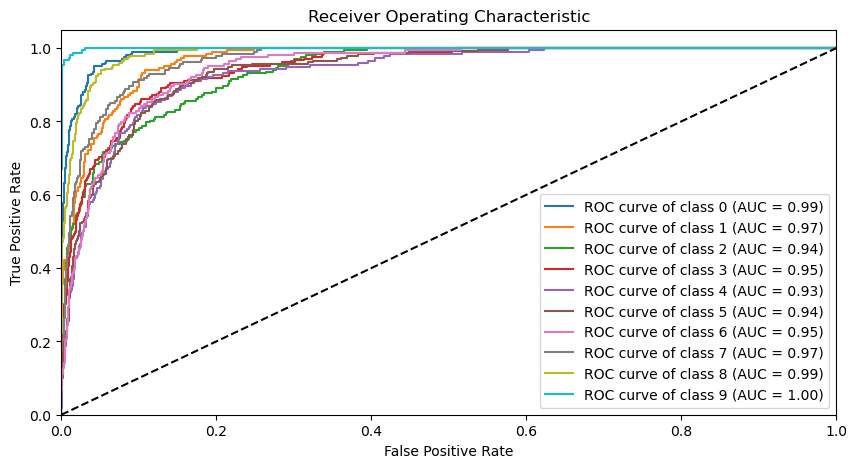

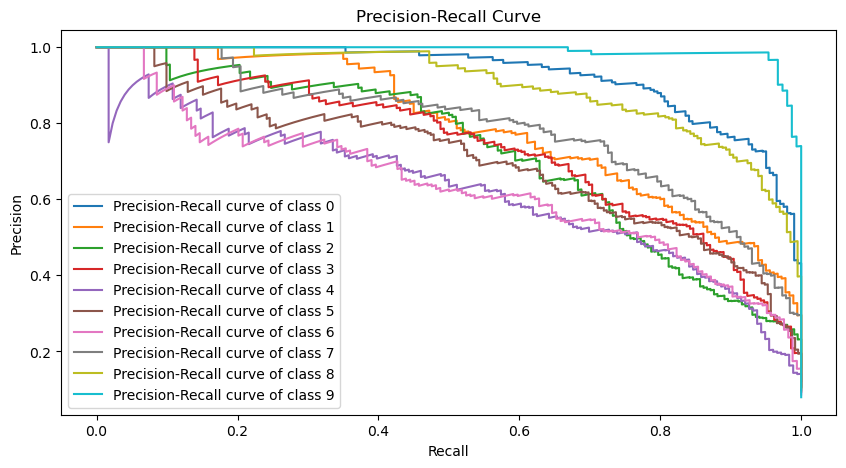

In [14]:
X = df.drop('target', axis=1)
y = df['target']


X_train, X_tests, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


rf = RandomForestClassifier(n_estimators=100,max_depth=10,min_samples_leaf=3,min_samples_split=5, random_state=42) #using a random parameters


rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)  


f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')

print(f'F1 Score: {f1:.4f}')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'ROC AUC Score: {roc_auc:.4f}')

# ROC curve
plt.figure(figsize=(10, 5))
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, i], pos_label=i)
    plt.plot(fpr, tpr, label=f'ROC curve of class {i} (AUC = {roc_auc_score(y_test == i, y_proba[:, i]):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# precision-recall curve
plt.figure(figsize=(10, 5))
for i in range(len(np.unique(y))):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba[:, i], pos_label=i)
    plt.plot(recall_vals, precision_vals, label=f'Precision-Recall curve of class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

## optimization and evaluation

Fitting 3 folds for each of 256 candidates, totalling 768 fits


C:\Users\shenl\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:1051: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan 

Best parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
F1 Score: 0.7543
Accuracy: 0.7555
Precision: 0.7573
Recall: 0.7555
ROC AUC Score: 0.9713


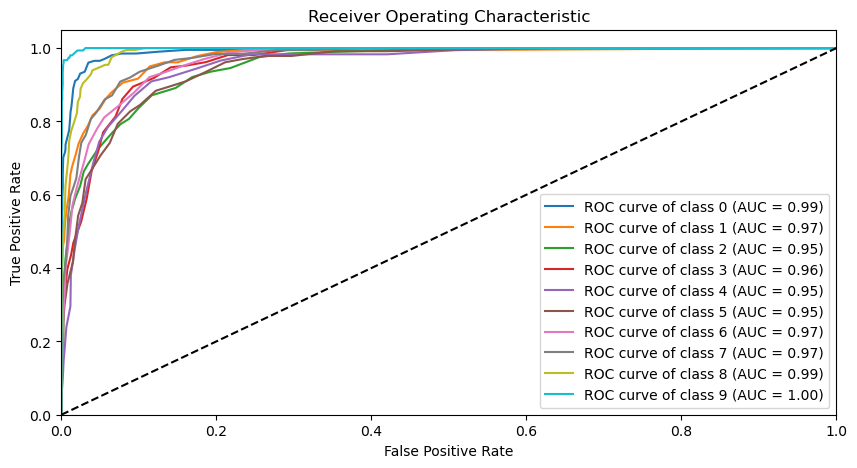

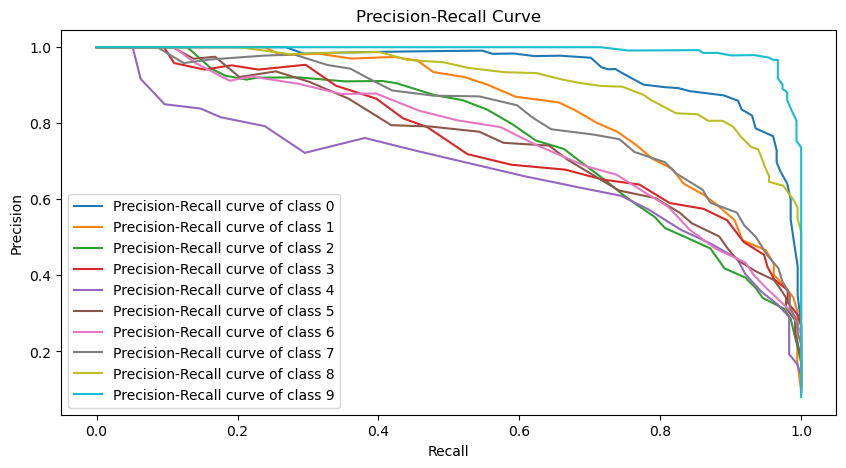

In [15]:
X = df.drop('target', axis=1)
y = df['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


param_grid = {
    'n_estimators': [50,100, 200,500],
    'max_depth': [None,10, 20,50],
    'min_samples_split': [2, 5, 10,50],
    'min_samples_leaf': [1, 2, 4,10]
}


rf = RandomForestClassifier(random_state=42)


grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='f1', verbose=3, n_jobs=-1)
grid_search.fit(X_train, y_train)


print('Best parameters:', grid_search.best_params_)


results = pd.DataFrame(grid_search.cv_results_)


best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)


y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)


f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr')

print(f'F1 Score: {f1:.4f}')
print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'ROC AUC Score: {roc_auc:.4f}')


plt.figure(figsize=(10, 5))
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_test, y_proba[:, i], pos_label=i)
    plt.plot(fpr, tpr, label=f'ROC curve of class {i} (AUC = {roc_auc_score(y_test == i, y_proba[:, i]):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


plt.figure(figsize=(10, 5))
for i in range(len(np.unique(y))):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba[:, i], pos_label=i)
    plt.plot(recall_vals, precision_vals, label=f'Precision-Recall curve of class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

Final Results on Test Set:
Final Accuracy: 0.8751
Final F1 Score: 0.8750
Final Recall: 0.8751
Final Precision: 0.8753
Final ROC AUC Score: 0.9927


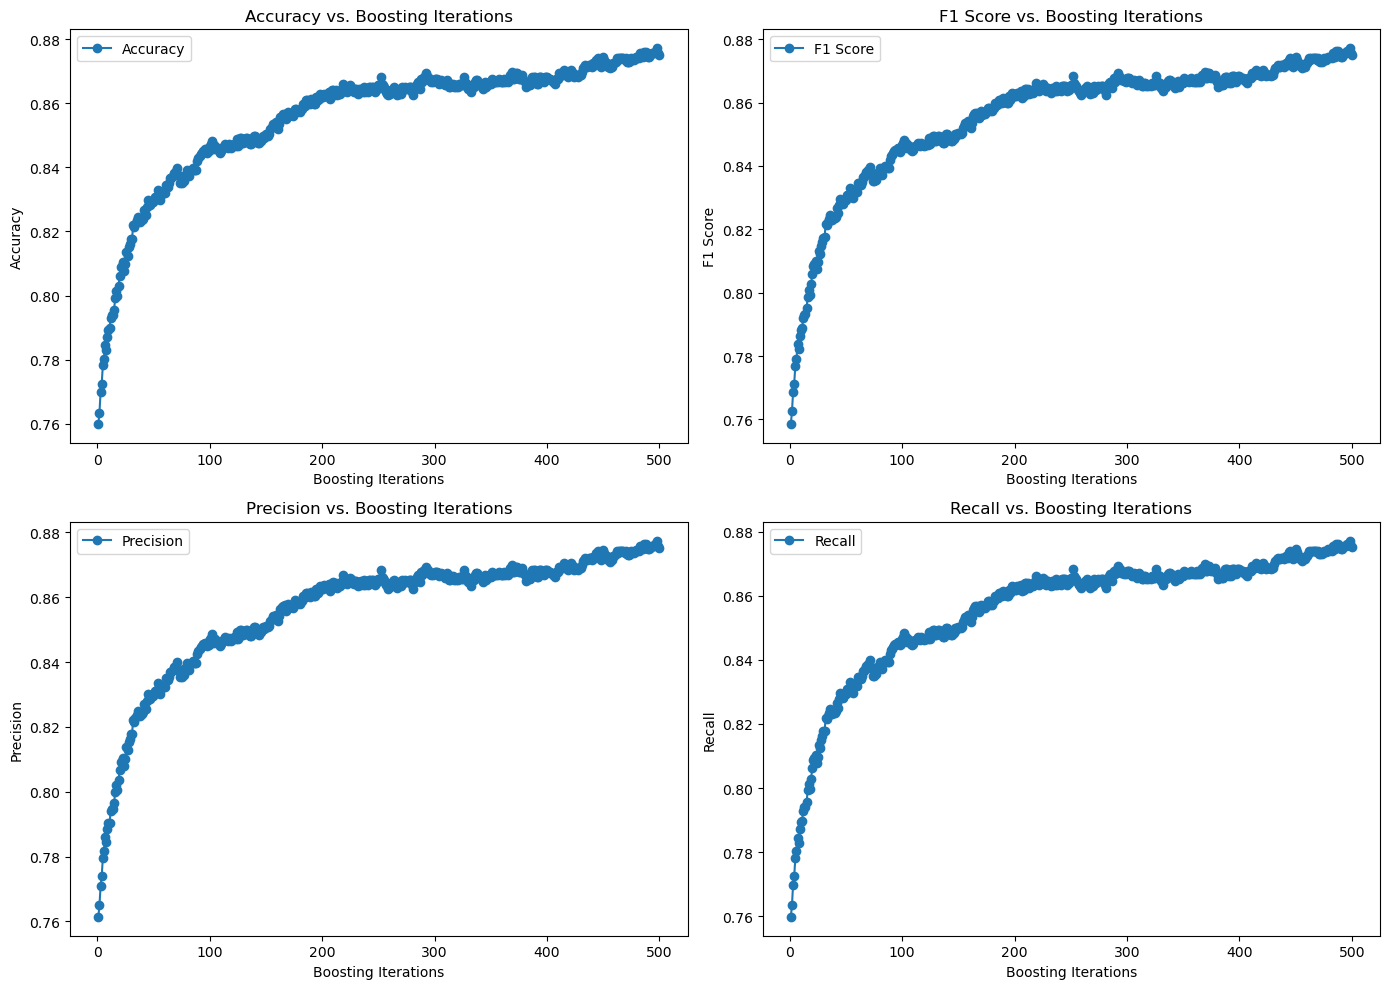

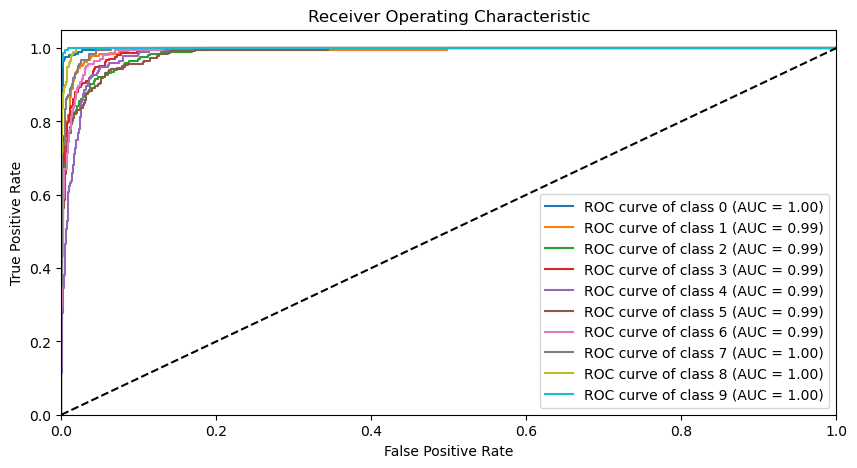

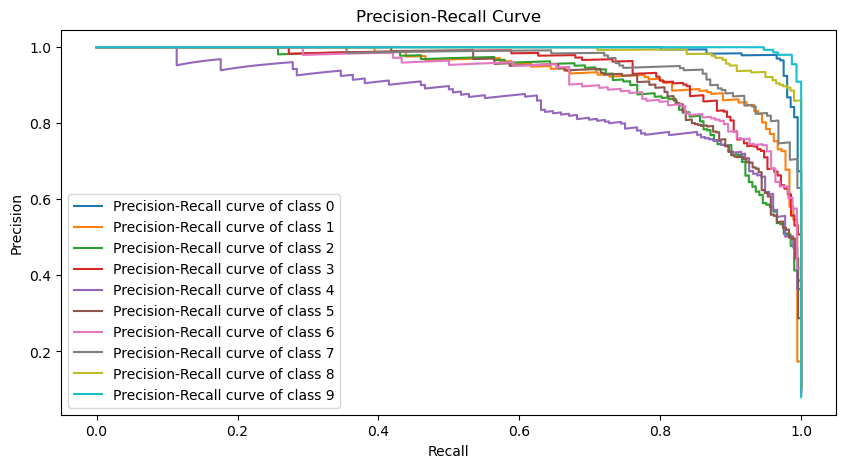

In [16]:
X = df.drop('target', axis=1)
y = df['target']


X_trains, X_tests, y_trains, y_tests = train_test_split(X, y, test_size=0.1, random_state=42)


base_rf = RandomForestClassifier(n_estimators=50,max_depth=None,min_samples_leaf=1,min_samples_split=2, random_state=42)


gb = GradientBoostingClassifier(init=base_rf, n_estimators=500, learning_rate=0.1, max_depth=3, random_state=42)


gb.fit(X_trains, y_trains)


acc_list = []
f1_list = []
recall_list = []
precision_list = []
roc_auc_list = []


for y_pred_staged, y_proba_staged in zip(gb.staged_predict(X_tests), gb.staged_predict_proba(X_tests)):
    acc_list.append(accuracy_score(y_tests, y_pred_staged))
    f1_list.append(f1_score(y_tests, y_pred_staged, average='weighted'))
    recall_list.append(recall_score(y_tests, y_pred_staged, average='weighted'))
    precision_list.append(precision_score(y_tests, y_pred_staged, average='weighted'))
    roc_auc_list.append(roc_auc_score(y_tests, y_proba_staged, multi_class='ovr'))


y_pred_final = gb.predict(X_tests)
y_proba_final = gb.predict_proba(X_tests)


final_acc = accuracy_score(y_tests, y_pred_final)
final_f1 = f1_score(y_tests, y_pred_final, average='weighted')
final_recall = recall_score(y_tests, y_pred_final, average='weighted')
final_precision = precision_score(y_tests, y_pred_final, average='weighted')
final_roc_auc = roc_auc_score(y_tests, y_proba_final, multi_class='ovr')


print("Final Results on Test Set:")
print(f"Final Accuracy: {final_acc:.4f}")
print(f"Final F1 Score: {final_f1:.4f}")
print(f"Final Recall: {final_recall:.4f}")
print(f"Final Precision: {final_precision:.4f}")
print(f"Final ROC AUC Score: {final_roc_auc:.4f}")


plt.figure(figsize=(14, 10))


plt.subplot(2, 2, 1)
plt.plot(range(1, len(acc_list) + 1), acc_list, label='Accuracy', marker='o')
plt.title('Accuracy vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(2, 2, 2)
plt.plot(range(1, len(f1_list) + 1), f1_list, label='F1 Score', marker='o')
plt.title('F1 Score vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('F1 Score')
plt.legend()


plt.subplot(2, 2, 3)
plt.plot(range(1, len(precision_list) + 1), precision_list, label='Precision', marker='o')
plt.title('Precision vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('Precision')
plt.legend()


plt.subplot(2, 2, 4)
plt.plot(range(1, len(recall_list) + 1), recall_list, label='Recall', marker='o')
plt.title('Recall vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_tests, y_proba_final[:, i], pos_label=i)
    plt.plot(fpr, tpr, label=f'ROC curve of class {i} (AUC = {roc_auc_score(y_tests == i, y_proba_final[:, i]):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


plt.figure(figsize=(10, 5))
for i in range(len(np.unique(y))):
    precision_vals, recall_vals, _ = precision_recall_curve(y_tests, y_proba_final[:, i], pos_label=i)
    plt.plot(recall_vals, precision_vals, label=f'Precision-Recall curve of class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

# Decision Tree flia0579

## 1. Import Libraries and Set Up the Environment

This part of the code is responsible for importing all the necessary libraries and setting up the environment for the project. It includes libraries for data processing (pandas, numpy), regular expression handling (re), model development (scikit-learn for tasks like train/test splitting, hyperparameter tuning, classifiers, etc.), and visualization (matplotlib).
The print_versions() function is used to print the versions of the libraries being used, ensuring that the current environment is correctly configured and compatible with the rest of the project.

In [2]:
# Import required libraries and set up the environment
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score, 
                             roc_auc_score, precision_recall_curve, roc_curve, 
                             confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay, 
                             PrecisionRecallDisplay)
import matplotlib.pyplot as plt
import matplotlib

# Function to print the versions of the libraries being used
def print_versions():
    print(f"pandas version: {pd.__version__}")
    print(f"numpy version: {np.__version__}")
    print(f"scikit-learn version: {GridSearchCV.__module__.split('.')[0]}=={GridSearchCV.__module__.split('.')[1]}")
    print(f"matplotlib version: {matplotlib.__version__}")
    print(f"re module is part of the Python standard library, no versioning needed.")

# Call the function to print library versions
print_versions()

pandas version: 2.2.2
numpy version: 1.26.4
scikit-learn version: sklearn==model_selection
matplotlib version: 3.8.4
re module is part of the Python standard library, no versioning needed.


## 2. Feature Engineering and Data Processing

Data Import and Initial Processing: The dataset is loaded from the classification.csv file, and unnecessary columns (like player ID, photo URL, etc.) are removed to clean the dataset.

Numerical Feature Conversion: Using regular expressions, features like height and weight are converted into a consistent format (centimeters and kilograms) to ensure that the decision tree model can correctly interpret and process the numerical data.

Label Encoding: Categorical features (such as country, club, preferred foot) are encoded into numerical values using LabelEncoder, so the model can handle non-numerical data.

Train-Test Split: The cleaned data is split into 90% training set and 10% test set, to ensure that the model is trained and evaluated on separate data, improving generalization.

### 2.1 Read file and Check data

In [5]:
# Load the dataset and display the first 5 rows
data = pd.read_csv('../data/classification.csv')
data.head()

,index,PlayerID,PlayerName,FullName,PhotoURL,PlayerURL,Country,Age,Rating in Scale 100,Potential in Scale 100,...,InternationalReputation,Pace,Shooting,Passing,Dribbling.1,Defending,Physical,PopularityHits,MarketValue_bins,MarketValue_category_euqal_freq
0,0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,...,5,85,92.0,91,95,38,65,771.0,"(5500000.0, 185500000.0]",9
1,1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,...,5,89,93.0,81,89,35,77,562.0,"(5500000.0, 185500000.0]",9
2,2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,...,3,87,92.0,78,90,52,90,150.0,"(5500000.0, 185500000.0]",9
3,3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,...,4,76,86.0,93,88,64,78,207.0,"(5500000.0, 185500000.0]",9
4,4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,...,5,91,85.0,86,94,36,59,595.0,"(5500000.0, 185500000.0]",9


### 2.2 Remove Unnecessary Columns

Since the data has already been preprocessed and the task is to predict the player’s market value range, we apply label encoding to string-based features like country. Unlike distance-based models, decision trees can handle label-encoded values without introducing errors related to incorrect ordering. Therefore, the next step is to remove unnecessary columns and train the decision tree model for prediction.

The following columns are primarily used for player identification and display purposes, and they do not contribute to predicting the player’s market value, abilities, or performance. Hence, these fields are dropped as they are not useful for model building:

	1.	Index: Represents the player’s unique identifier or sequence number.
	2.	PlayerID: A unique identifier assigned to each player, usually numerical.
	3.	PlayerName: The player’s common name or nickname.
	4.	FullName: The player’s full name.
	5.	PhotoURL: The URL for the player’s photo.
	6.	PlayerURL: The URL for the player’s profile page.

These fields are for data management and player information display, but they do not directly influence the player’s market value. Therefore, they are excluded from the predictive model.

Next, the following market value-related fields are also removed:

	1.	MarketValue: The player’s current market value, which is already represented as a label.
	2.	MarketValue_bins: The player’s market value grouped into ranges. Since we have transformed these into labeled categories (MarketValue_category_equal_freq), only this final category column is retained.

Additionally, fields like height and weight are converted to float types for proper handling by the decision tree during training.

In [7]:
# Remove irrelevant columns that don't contribute to prediction
data = data.drop(columns=['index', 'PlayerID', 'PlayerName', 'FullName', 'PhotoURL', 'PlayerURL', 'MarketValue_bins', 'MarketValue'])

# Drop 'LoanEndDate' due to excessive missing values
data = data.drop(columns='LoanEndDate')

# Identify and display all columns with object (string) types that may need encoding
features = data.dtypes[data.dtypes == "object"].index
print("features: ", features)

# Convert height values to a uniform format (centimeters)
data['Height'] = data['Height'].apply(
    lambda x: int(re.findall(r'\d+', x)[0]) if 'cm' in x 
    else round(int(re.findall(r"(\d+)'", x)[0]) * 30.48 + int(re.findall(r'(\d+)"', x)[0]) * 2.54, 2)
)

# Convert weight values to kilograms
data['Weight'] = data['Weight'].apply(
    lambda x: int(re.findall(r'\d+', x)[0]) if 'kg' in x 
    else round(int(re.findall(r'\d+', x)[0]) * 0.453592, 2)
)

# Convert 'WeeklyWage' from K to numerical values in thousands
data['WeeklyWage'] = data['WeeklyWage'].apply(lambda x: float(x.replace('K', '')) * 1000)

# Convert 'ReleaseClause' from M or K to numerical values (millions or thousands)
data['ReleaseClause'] = data['ReleaseClause'].apply(
    lambda x: float(str(x).replace('M', '')) if 'M' in str(x) 
    else float(str(x).replace('K', '')) / 1000
)

# Extract the year from 'DateJoined' and store as a numerical value
data['DateJoined'] = data['DateJoined'].apply(lambda x: x.split('-')[-1])

# Display the cleaned and converted DataFrame
data[['Height', 'Weight','WeeklyWage','ReleaseClause','DateJoined']]

features:  Index(['Country', 'CurrentClub', 'ContractInfo', 'PlayingPositions', 'Height',
       'Weight', 'PreferredFoot', 'BestPosition', 'DateJoined', 'WeeklyWage',
       'ReleaseClause', 'AttackingWorkRate', 'DefensiveWorkRate'],
      dtype='object')


,Height,Weight,WeeklyWage,ReleaseClause,DateJoined
0,170.0,72.0,560000.0,138.400,04
1,187.0,83.0,220000.0,75.900,18
2,188.0,87.0,125000.0,159.400,14
3,181.0,70.0,370000.0,161.000,15
4,175.0,68.0,270000.0,166.500,17
...,...,...,...,...,...
18974,178.0,66.0,1000.0,0.070,18
18975,175.0,65.0,500000.0,0.165,20
18976,179.0,74.0,500000.0,0.131,19
18977,175.0,69.0,2000.0,0.088,20


### 2.3 Label Encoding of Categorical Features

For categorical features such as 'Country', 'CurrentClub', 'ContractInfo', 'PlayingPositions', 'PreferredFoot', 'BestPosition', 'AttackingWorkRate', and 'DefensiveWorkRate', we apply label encoding to convert string-type categories into numerical labels. This is necessary because decision trees can process label-encoded data, and since they are not distance-based models, they can handle encoded values without introducing ordering issues.

Label encoding assigns each unique category a numerical value, enabling the model to work with categorical features efficiently.

In [9]:
# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Simplified label encoding for multiple columns using a loop
columns_to_encode = ['Country', 'CurrentClub', 'ContractInfo', 'PlayingPositions', 'PreferredFoot', 
                     'BestPosition', 'AttackingWorkRate', 'DefensiveWorkRate']

# Apply label encoding to each of the specified columns
for column in columns_to_encode:
    data[column] = label_encoder.fit_transform(data[column])


# To inverse transform and revert the encoded values back to the original years
# date['YearJoined'] = label_encoder.inverse_transform(date['YearJoined_Encoded'])

# Display the DataFrame with the encoded column
data[['Country', 'CurrentClub', 'ContractInfo', 'PlayingPositions', 'PreferredFoot', 'BestPosition', 'AttackingWorkRate','DefensiveWorkRate']]

,Country,CurrentClub,ContractInfo,PlayingPositions,PreferredFoot,BestPosition,AttackingWorkRate,DefensiveWorkRate
0,6,214,8,564,0,12,2,1
1,124,339,87,614,1,14,0,1
2,139,64,62,221,1,5,2,2
3,14,386,69,10,1,0,0,0
4,20,452,81,345,1,8,0,2
...,...,...,...,...,...,...,...,...
18974,30,671,87,56,1,1,2,2
18975,47,433,99,155,1,0,2,2
18976,47,189,91,155,1,0,2,2
18977,30,178,100,523,1,14,2,2


### 2.4 Split train data and test data

In this step, the dataset is split into features (X) and the target variable (y), where the target variable is the MarketValue_category_equal_freq. The dataset is then divided into 90% training data and 10% test data. This is crucial for model evaluation, as it allows us to train the model on the majority of the data while keeping a separate portion of the data for performance evaluation.

In [11]:
# Assign the target variable 'MarketValue_category_equal_freq' to y
y = data.loc[:, "MarketValue_category_euqal_freq"]

# Drop the target column from the dataset, keeping only features for X
data = data.drop(columns='MarketValue_category_euqal_freq')
X = data

# Split the dataset into 90% training data and 10% test data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

# Output the shape of the training and test sets
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train: (17081, 70)
X_test: (1898, 70)


## 3. Model Building and Hyperparameter Optimization

In this section, I first build an initial decision tree model using DecisionTreeClassifier and evaluate its performance on the training and test sets. And then perform hyperparameter optimization using GridSearchCV to find the best combination of hyperparameters that improve the model’s performance. Finally, visualize the model’s performance using ROC curves and Precision-Recall curves to get deeper insights into how the model handles different classes.

### 3.1 Base Model Decision Tree

In this section, I set up the base decision tree model using DecisionTreeClassifier and evaluate its performance on the training and test datasets.

In [14]:
# Initial Decision Tree model with default hyperparameters
tree = DecisionTreeClassifier(criterion='entropy', max_depth=15, random_state=42)
tree.fit(X_train, y_train)

# Evaluate the model's performance on training and test sets
print("Accuracy on training set: {:.3f}".format(tree.score(X_train, y_train)))
print("Accuracy on test set: {:.3f}".format(tree.score(X_test, y_test)))

Accuracy on training set: 0.994
Accuracy on test set: 0.780


f1:  0.7806969797318347
accuracy:  0.7802950474183351
precision:  0.7820294179482152
recall:  0.7802950474183351
roc_auc:  0.8828161651928212


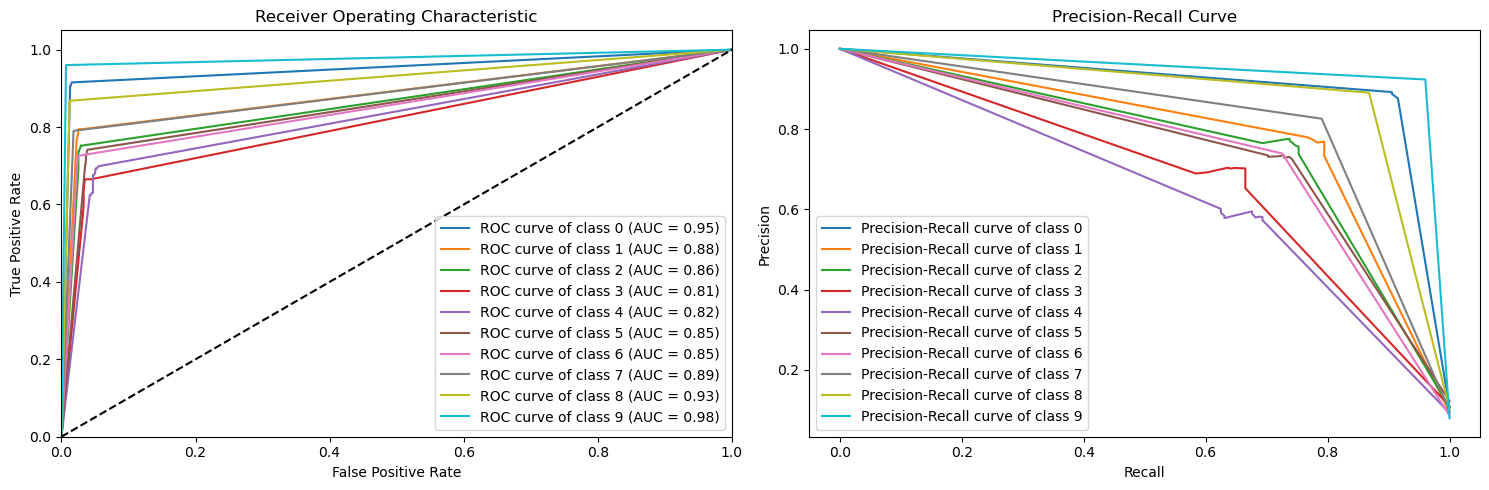

In [19]:
# Predict on test set and calculate probabilities
y_pred_tree = tree.predict(X_test)
y_prob_tree = tree.predict_proba(X_test)

# Calculate performance metrics
f1 = f1_score(y_test, y_pred_tree, average='weighted')
accuracy = accuracy_score(y_test, y_pred_tree)
precision = precision_score(y_test, y_pred_tree, average='weighted')
recall = recall_score(y_test, y_pred_tree, average='weighted')
roc_auc = roc_auc_score(y_test, y_prob_tree, multi_class='ovr')

# Print performance metrics
print("F1 Score: ", f1)
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("ROC AUC: ", roc_auc)


# ROC curve
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ROC
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_test, y_prob_tree[:, i], pos_label=i)
    ax[0].plot(fpr, tpr, label=f'ROC curve of class {i} (AUC = {roc_auc_score(y_test == i, y_prob_tree[:, i]):.2f})')

ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Receiver Operating Characteristic')
ax[0].legend(loc="lower right")

# Precision-Recall
for i in range(len(np.unique(y))):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_tree[:, i], pos_label=i)
    ax[1].plot(recall_vals, precision_vals, label=f'Precision-Recall curve of class {i}')

ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")

# show graph
plt.tight_layout()
plt.show()

### 3.2 Grid Search Optimization

In this section, I will perform hyperparameter tuning on the decision tree model using GridSearchCV. The four key hyperparameters being optimized are:

max_depth: Controls the depth of the tree

criterion: Decides the function to measure the quality of a split (gini for Gini impurity or entropy for information gain).

min_samples_split: The minimum number of samples required to split an internal node.

min_samples_leaf: The minimum number of samples required to be at a leaf node.

Once the grid search identifies the optimal combination of hyperparameters, I will retrain the model using those parameters and evaluate its performance.


In [22]:
# Parameter grid, tune hyperparameters ： max_depth，criterion，min_samples_split，min_samples_leaf

'''
Here's the translation for the parameters:

max_depth: The maximum depth of the decision tree, which refers to the longest path from the root to a leaf. It controls the complexity of the tree.
  
criterion: The criterion for evaluating the split quality.
           gini: Gini impurity, measures the purity of the samples in a node; lower values are better.
           entropy: Information entropy, measures the level of disorder or uncertainty; features are chosen to minimize entropy during splits.

min_samples_split: The minimum number of samples required to split an internal node.

min_samples_leaf: The minimum number of samples required to be at a leaf node.
'''

base_tree = DecisionTreeClassifier(criterion='entropy',random_state=42)

param_grid = {
    'max_depth': [7,9,11,13,15,17],
    'min_samples_split': [5,7,9,10,13,15,17,20,22,25],
    'min_samples_leaf': [3,4,5,6,7,8,9,10,11,13,15,17,20],
    'criterion': ['gini', 'entropy'],
}

grid_search = GridSearchCV(estimator=base_tree, param_grid=param_grid, cv=10, n_jobs=-1, verbose=3)

grid_search.fit(X_train, y_train)

# Output the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Use the best model to make predictions on the test set
best_tree = grid_search.best_estimator_
y_pred_tree = best_tree.predict(X_test)

# Calculate accuracy on the test set.
accuracy = accuracy_score(y_test, y_pred_tree)
print(f"Best Decision Tree - accuracy on test set: {accuracy:.2f}")

Fitting 10 folds for each of 1560 candidates, totalling 15600 fits
[CV 1/10] END criterion=gini, max_depth=7, min_samples_leaf=3, min_samples_split=5;, score=0.668 total time=   0.7s
[CV 10/10] END criterion=gini, max_depth=7, min_samples_leaf=3, min_samples_split=5;, score=0.681 total time=   0.7s
[CV 7/10] END criterion=gini, max_depth=7, min_samples_leaf=3, min_samples_split=7;, score=0.647 total time=   0.6s
[CV 5/10] END criterion=gini, max_depth=7, min_samples_leaf=3, min_samples_split=9;, score=0.667 total time=   0.8s
[CV 4/10] END criterion=gini, max_depth=7, min_samples_leaf=3, min_samples_split=10;, score=0.653 total time=   0.7s
[CV 2/10] END criterion=gini, max_depth=7, min_samples_leaf=3, min_samples_split=13;, score=0.680 total time=   0.8s
[CV 3/10] END criterion=gini, max_depth=7, min_samples_leaf=3, min_samples_split=15;, score=0.668 total time=   0.7s
[CV 1/10] END criterion=gini, max_depth=7, min_samples_leaf=3, min_samples_split=17;, score=0.668 total time=   0.8s


f1:  0.8015411386866588
accuracy:  0.8018967334035827
precision:  0.8022486518259809
recall:  0.8018967334035827
roc_auc:  0.9501873119319312


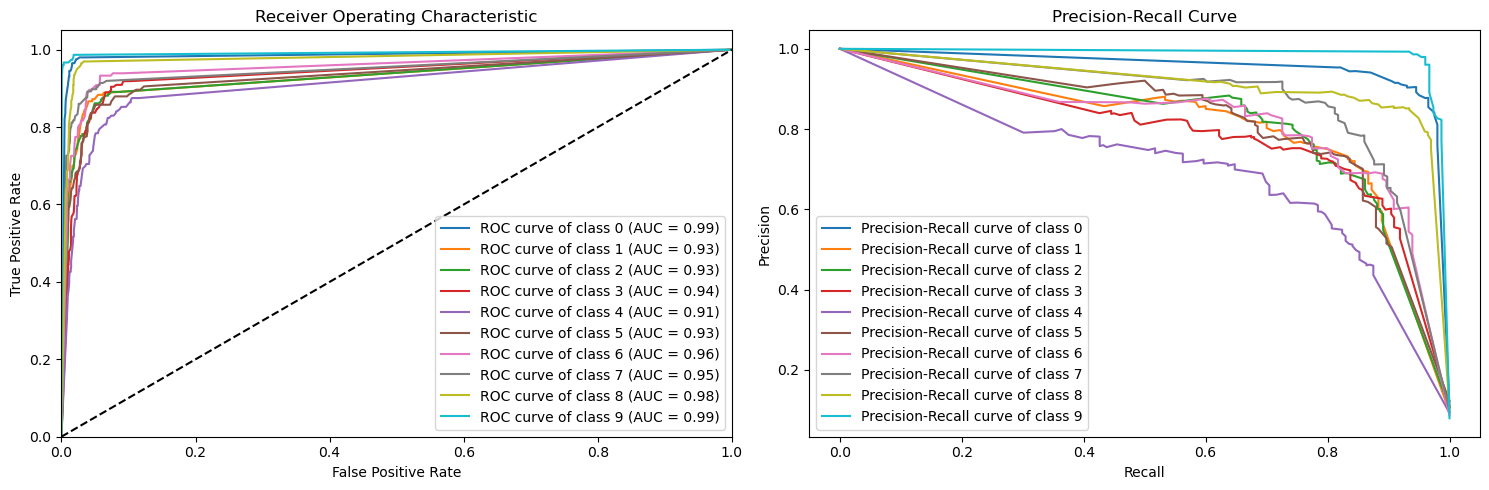

In [26]:
y_pred_best_tree = best_tree.predict(X_test)
# this calculates the probability of each class
y_prob_best_tree = best_tree.predict_proba(X_test)


f1 = f1_score(y_test, y_pred_best_tree, average='weighted')
accuracy = accuracy_score(y_test, y_pred_best_tree)
precision = precision_score(y_test, y_pred_best_tree, average='weighted')
recall = recall_score(y_test, y_pred_best_tree, average='weighted')
roc_auc = roc_auc_score(y_test, y_prob_best_tree, multi_class='ovr')

print("f1: ",f1)
print("accuracy: ",accuracy)
print("precision: ",precision)
print("recall: ",recall)
print("roc_auc: ",roc_auc)

# beautiful graph
# ROC curve
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ROC 
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_test, y_prob_best_tree[:, i], pos_label=i)
    ax[0].plot(fpr, tpr, label=f'ROC curve of class {i} (AUC = {roc_auc_score(y_test == i, y_prob_best_tree[:, i]):.2f})')

ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Receiver Operating Characteristic')
ax[0].legend(loc="lower right")

# Precision-Recall
for i in range(len(np.unique(y))):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob_best_tree[:, i], pos_label=i)
    ax[1].plot(recall_vals, precision_vals, label=f'Precision-Recall curve of class {i}')

ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")

#
plt.tight_layout()
plt.show()

### 3.3 Bagging Model Ensemble

In this section, I use BaggingClassifier to apply bagging (bootstrap aggregating) on the decision tree model. Bagging helps to reduce the variance of the model and improve its generalization ability. By creating multiple subsets of the training data (with replacement), several decision tree models are trained independently, and their predictions are aggregated through voting or averaging, leading to a final prediction.

In [32]:
# BaggingClassifier parameters
'''
'n_estimators': # Number of base estimators (trees) in the ensemble
'max_samples':  # The fraction of samples to draw from the training set to train each base estimator
'bootstrap':    # Whether samples are drawn with replacement (True) or without replacement (False)
'''

# Initialize BaggingClassifier with optimized decision tree as the base estimator
bag_clf = BaggingClassifier(
    best_tree,  # Using the optimized decision tree model
    n_estimators=500,          # Train 500 trees
    max_samples=0.5,           # Each tree is trained on 50% of the data
    bootstrap=False,           # Sampling without replacement
    random_state=42            # Set random state for reproducibility
)

# Fit the BaggingClassifier on the training data
bag_clf.fit(X_train, y_train)

# Make predictions on the test set
y_pred = bag_clf.predict(X_test)

# Calculate and print the accuracy of the Bagging ensemble on the test set
print("Bagging ensemble of decision trees - accuracy on test set:")
print(accuracy_score(y_test, y_pred))

[CV 7/10] END criterion=entropy, max_depth=15, min_samples_leaf=17, min_samples_split=22;, score=0.778 total time=   0.7s
[CV 5/10] END criterion=entropy, max_depth=15, min_samples_leaf=17, min_samples_split=25;, score=0.773 total time=   0.7s
[CV 3/10] END criterion=entropy, max_depth=15, min_samples_leaf=20, min_samples_split=5;, score=0.780 total time=   0.7s
[CV 1/10] END criterion=entropy, max_depth=15, min_samples_leaf=20, min_samples_split=7;, score=0.783 total time=   0.6s
[CV 9/10] END criterion=entropy, max_depth=15, min_samples_leaf=20, min_samples_split=7;, score=0.775 total time=   0.7s
[CV 7/10] END criterion=entropy, max_depth=15, min_samples_leaf=20, min_samples_split=9;, score=0.763 total time=   0.7s
[CV 5/10] END criterion=entropy, max_depth=15, min_samples_leaf=20, min_samples_split=10;, score=0.771 total time=   0.7s
[CV 3/10] END criterion=entropy, max_depth=15, min_samples_leaf=20, min_samples_split=13;, score=0.780 total time=   0.8s
[CV 1/10] END criterion=entr

To compute the evaluation metrics (such as F1 score, precision, recall, ROC-AUC), and to visualize the ROC and Precision-Recall

f1:  0.8522168315247555
accuracy:  0.8519494204425712
precision:  0.8528584144803376
recall:  0.8519494204425712
roc_auc:  0.9886625821056635


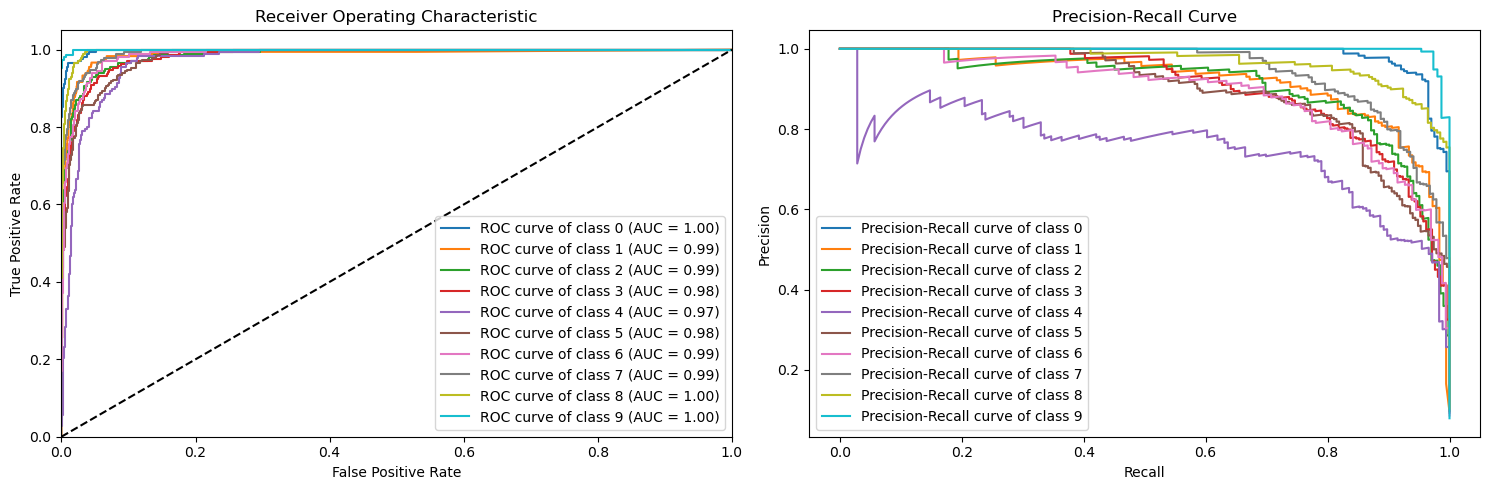

In [34]:
y_pred = bag_clf.predict(X_test)
y_probability = bag_clf.predict_proba(X_test)


f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_probability, multi_class='ovr')

print("f1: ",f1)
print("accuracy: ",accuracy)
print("precision: ",precision)
print("recall: ",recall)
print("roc_auc: ",roc_auc)

# beautiful graph
# ROC curve
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ROC
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_test, y_probability[:, i], pos_label=i)
    ax[0].plot(fpr, tpr, label=f'ROC curve of class {i} (AUC = {roc_auc_score(y_test == i, y_probability[:, i]):.2f})')

ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Receiver Operating Characteristic')
ax[0].legend(loc="lower right")

# Precision-Recall
for i in range(len(np.unique(y))):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_probability[:, i], pos_label=i)
    ax[1].plot(recall_vals, precision_vals, label=f'Precision-Recall curve of class {i}')

ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")

# show
plt.tight_layout()
plt.show()

## 4. Conclusion

### 4.1 The meaning of indicators:

1. F1 Score: The F1 score is the harmonic average of Precision and Recall, synthesizing the model's balance between capturing positive class (Recall rate) and predicting positive class accuracy (Precision rate). The higher the F1 score, the better the model is at capturing positive classes and reducing misclassifications.
2. Accuracy: Accuracy refers to the proportion of samples predicted correctly by the model in all samples. It measures how accurate the model's overall predictions are. Especially in the case of unbalanced categories, relying solely on accuracy can be misleading because it ignores the balance of positive and negative classes.
3. Precision: Precision represents the proportion of samples predicted to be positive that are actually positive. The high-precision representation model reduces false positives, that is, the misclassification of negative classes into positive ones.
4. Recall: Recall represents the proportion of samples that are correctly predicted to be positive among the samples that are actually positive. The high recall rate means that the model can capture more positive samples and reduce missed reports (false negatives).
5. ROC AUC: The Area Under Curve (AUC) measures the classification ability of the model. The closer the AUC is to 1, the more accurately the model can distinguish between positive and negative classes. The AUC provides model performance at different thresholds and is a comprehensive assessment of the overall classification capability.

### 4.2 Basic decision tree model:

F1 Score: 0.7807
Accuracy: 0.7803
Precision: 0.7820
Recall: 0.7803
ROC AUC: 0.8828


From the ROC curve of the first model, it can be seen that the AUC of each class is mostly between 0.81 and 0.95, indicating that the classification ability of the basic decision tree is relatively good, especially class 0 (AUC=0.95).
The Precision-Recall curve shows low recall rates for some categories (e.g., class 4, class 5, class 3), indicating that the model has a certain underreporting problem in these categories.
Overall, the performance of the basic decision tree model is good, but the classification ability of some categories is insufficient, and there may be some misclassification and missing reports.

### 4.3 Optimal decision tree model:

F1 Score: 0.8015
Accuracy: 0.8019
Precision: 0.8022
Recall: 0.8019
ROC AUC: 0.9502



After using grid search to optimize hyperparameters, all indicators of the model were significantly improved, F1 score, accuracy, accuracy and recall rate were significantly increased, especially ROC AUC was increased from 0.88 to 0.95.
The AUC value of ROC curve increased significantly, especially for class 3, class 4, class 5 and other categories, indicating that the optimized model has improved the ability to distinguish more categories.
The Precision-Recall curve also shows significant improvements in recall and accuracy in most categories, with class 4 and class 5 in particular no longer performing as poorly as the base model.

### 4.4 Bagging model:

F1 Score: 0.8522
Accuracy: 0.8519
Precision: 0.8529
Recall: 0.8519
ROC AUC: 0.9887



The Bagging model further improves the overall performance, and all indicators are improved compared with the optimal decision tree model, especially the ROC AUC is increased from 0.95 to 0.99, indicating that the model's ability to distinguish positive and negative classes reaches a high level.
The AUC values of class 0, class 1, class 8, and class 9 in the ROC curve are all close to 1.00, indicating that the classification effect of these classes is almost perfect.

The precision-recall curve also shows that the Precision rate and Recall rate of the model have been improved in all categories, especially in class 4, class 5 and other difficult categories, the model performance is more stable.

### 4.5 Conclusion:

1. Basic decision tree: The performance is relatively average, some categories (such as class 4, class 5, class 3) perform poorly, and the ROC AUC and F1 scores are low, which may lead to misclassification and missing reporting.
2. Optimal decision tree: After optimizing hyperparameters through grid search, the model has a significant improvement in all indicators. The ROC AUC reached 0.95, and the accuracy and recall rate were also significantly improved, indicating that hyperparameter optimization was obviously helpful to the improvement of model performance.
3. Bagging Model: After Bagging integration, the variance of the model is further reduced, and the classification performance of all categories is improved, especially the ROC AUC is close to 1.0, and the F1 score reaches 0.85, which indicates that Bagging model has advantages in handling noise and improving generalization ability. The resulting Bagging model performs best on classification tasks.

Overall, the Bagging model provides the strongest performance, significantly outperforming both the basic decision tree and the optimal decision tree.

# Logistic Regression ikha0128

## preprocessing

**Ingesting the data**

Adding required header and ingesting the data using panada 

In [1021]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import  classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import classification_report, accuracy_score, auc
import re
#from sklearn.model_selection import StratifiedKFold
#from mlxtend.frequent_patterns import fpgrowth
#from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import LogisticRegression

pd.set_option('future.no_silent_downcasting', False)
dataFile = 'classification.csv'
countriesFile = "football_clubs_with_country_income_final.csv"
dataFrame = pd.read_csv(dataFile);
clubInfo = pd.read_csv(countriesFile)
dataFrame.head()

,index,PlayerID,PlayerName,FullName,PhotoURL,PlayerURL,Country,Age,Rating in Scale 100,Potential in Scale 100,...,InternationalReputation,Pace,Shooting,Passing,Dribbling.1,Defending,Physical,PopularityHits,MarketValue_bins,MarketValue_category_euqal_freq
0,0,158023,L. Messi,Lionel Messi,https://cdn.sofifa.com/players/158/023/21_60.png,http://sofifa.com/player/158023/lionel-messi/2...,Argentina,33,93,93,...,5,85,92.0,91,95,38,65,771.0,"(5500000.0, 185500000.0]",9
1,1,20801,Cristiano Ronaldo,C. Ronaldo dos Santos Aveiro,https://cdn.sofifa.com/players/020/801/21_60.png,http://sofifa.com/player/20801/c-ronaldo-dos-s...,Portugal,35,92,92,...,5,89,93.0,81,89,35,77,562.0,"(5500000.0, 185500000.0]",9
2,2,200389,J. Oblak,Jan Oblak,https://cdn.sofifa.com/players/200/389/21_60.png,http://sofifa.com/player/200389/jan-oblak/210006/,Slovenia,27,91,93,...,3,87,92.0,78,90,52,90,150.0,"(5500000.0, 185500000.0]",9
3,3,192985,K. De Bruyne,Kevin De Bruyne,https://cdn.sofifa.com/players/192/985/21_60.png,http://sofifa.com/player/192985/kevin-de-bruyn...,Belgium,29,91,91,...,4,76,86.0,93,88,64,78,207.0,"(5500000.0, 185500000.0]",9
4,4,190871,Neymar Jr,Neymar da Silva Santos Jr.,https://cdn.sofifa.com/players/190/871/21_60.png,http://sofifa.com/player/190871/neymar-da-silv...,Brazil,28,91,91,...,5,91,85.0,86,94,36,59,595.0,"(5500000.0, 185500000.0]",9


**Helper Functions**

Below is helper function to validate that many of the numeric columns are actually reduntant and can be ignored based on the PlayersPositions Column in the data

In [1022]:
def validate_grouping(data, target_attribute):
    """Check if a target attribute is mostly in a specific cluster"""
    dataCopy = data.copy()
    predicted = dataCopy['predicted'] == dataCopy[target_attribute].replace(re.compile('^(?!True)'), 0).replace('True',1)
    predicted = predicted.to_frame()
    group = predicted.groupby(predicted.columns[0]).size()
    trueCount = group[True] if True in group.keys() else 0
    falseCount = group[False]  if False in group.keys() else 0
    return (trueCount/ (trueCount + falseCount)) > 0.5
def calculate_roc(y_kmeans, true_labels) :
    # Step 2: Assign cluster labels
    # KMeans clusters don't correspond to actual labels, so map the clusters to 0 or 1 based on centroids or class majority
    # Here, we'll assume cluster 0 corresponds to class 0, and cluster 1 corresponds to class 1
    # You may need to adjust this based on your data
    y_kmeans_mapped = np.where(y_kmeans == 0, 0, 1)  # Map cluster 0 to 0, cluster 1 to 1

    # Step 3: Calculate AUC-ROC
    auc_roc = roc_auc_score(true_labels, y_kmeans_mapped)

    # Step 4: Calculate ROC Curve
    fpr, tpr, thresholds = roc_curve(true_labels, y_kmeans_mapped)

    # Step 5: Plot ROC Curve
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc_roc:.2f}")
    plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line (random classifier)
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve')
    plt.legend(loc="lower right")
    plt.show()

def validateAttriuteWithPosition(data, columns_of_interest, labels):
    dataCopy = data.copy()
    dataCopy.replace(r'^\s*$', np.nan, regex=True)
    predictedColumn = 'predicted'
    for column in columns_of_interest:
        # Convert the column to numeric type; set non-numeric values to NaN
        dataCopy[column] = pd.to_numeric(dataCopy[column], errors="coerce")
    
        # Drop rows containing NaN in the column
        dataCopy.dropna(subset=[column], inplace=True)

    X = (dataCopy[columns_of_interest].sum(axis=1)/dataCopy['TotalStats']).to_frame()
 
    # Standardize the data (important for clustering algorithms)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Apply KMeans clustering
    kmeans = KMeans(n_clusters=2, random_state=42)  # only two clusters
    dataCopy[predictedColumn] = kmeans.fit_predict(X_scaled)
    # search for string in PlayingPosition and set to true
    for label in labels: 
        dataCopy['BestPosition'] = dataCopy['BestPosition'].replace(re.compile('.*%s.*'%label), 'True')
    # anything thats not true is false also make boolean
    isGroupingRight = validate_grouping(dataCopy,'BestPosition')
    true_labels =  dataCopy['BestPosition'].replace(re.compile('^(?!True)'), 0).replace('True',1) if isGroupingRight else dataCopy['BestPosition'].replace(re.compile('^(?!True)'), 1).replace('True',0)
    calculate_roc(kmeans.fit_predict(X),true_labels)
    report = classification_report(true_labels, dataCopy[predictedColumn])
    if predictedColumn in data.columns:
        data.drop(column=[predictedColumn])
    return report , isGroupingRight


**Reduction By Clustering [GoalKeeper or GK]**
Reducing goal keeper data



In [1023]:
def ensureKeysSumsUpTo(data,columns_of_interest, summingColumn ):
    # Summing up the attacking skills
    df = data.copy()
    df['skill'] = df[columns_of_interest].sum(axis=1)

    # Compare the summed attacking skills with the provided 'Attacking Skills' value
    df['match'] = df['skill'] == df[summingColumn]
    print(df.groupby('match')['match'].size())
    # actual = df.groupby('match').size()[True]
    # print(actual)
    # count = len(df.index)
    # print(count)
    return False

/var/folders/lh/fl36f4wn535c8blqx0lwhgnc0000gn/T/ipykernel_3801/2939628894.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predicted = dataCopy['predicted'] == dataCopy[target_attribute].replace(re.compile('^(?!True)'), 0).replace('True',1)
/var/folders/lh/fl36f4wn535c8blqx0lwhgnc0000gn/T/ipykernel_3801/2939628894.py:58: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  true_labels =  dataCopy['BestPosition'].replace(re.compile('^(?!True)'), 0).replace('True',1) if isGroupingRight else dataCopy['BestPosition'].replace(re.compile('

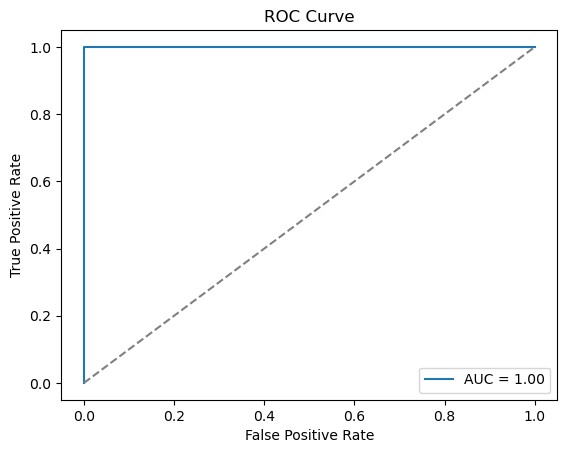

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16904
           1       1.00      1.00      1.00      2075

    accuracy                           1.00     18979
   macro avg       1.00      1.00      1.00     18979
weighted avg       1.00      1.00      1.00     18979
 True


In [1024]:

matrix = validateAttriuteWithPosition(dataFrame, list(filter( lambda x: x.lower().startswith('goalkeep') ,dataFrame.columns)),['GK'])

print(matrix[0], matrix[1])

According to the results we will remove columns 
Note the precesion is 1 which means that it is a total redundant data 

In [1025]:
dataFrame= dataFrame.drop(columns=list(filter( lambda x: x.lower().startswith('goalkeep'),dataFrame.columns)))

/var/folders/lh/fl36f4wn535c8blqx0lwhgnc0000gn/T/ipykernel_3801/2939628894.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predicted = dataCopy['predicted'] == dataCopy[target_attribute].replace(re.compile('^(?!True)'), 0).replace('True',1)
/var/folders/lh/fl36f4wn535c8blqx0lwhgnc0000gn/T/ipykernel_3801/2939628894.py:58: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  true_labels =  dataCopy['BestPosition'].replace(re.compile('^(?!True)'), 0).replace('True',1) if isGroupingRight else dataCopy['BestPosition'].replace(re.compile('

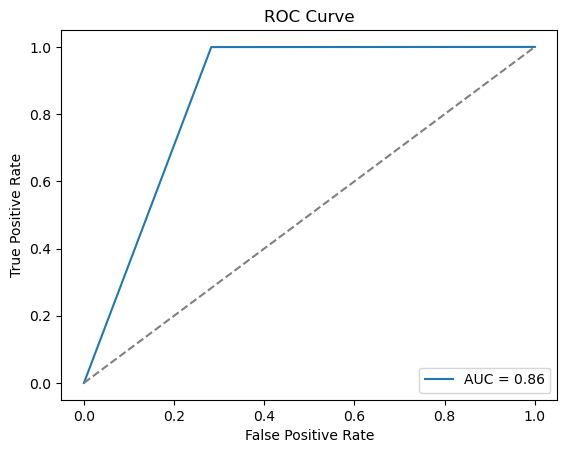

              precision    recall  f1-score   support

           0       1.00      0.72      0.84     12590
           1       0.64      1.00      0.78      6389

    accuracy                           0.81     18979
   macro avg       0.82      0.86      0.81     18979
weighted avg       0.88      0.81      0.82     18979
 True


In [1026]:
matrix = validateAttriuteWithPosition(dataFrame, ['Strength','Aggression','Interceptions','DefendingSkills','Marking','StandingTackle','SlidingTackle','Defending','JumpingAbility'] ,['CB', 'LB','RB','LWB','RWB'])

print(matrix[0], matrix[1])

**Defenders Conclusion**
The classifier has strong precision in predicting false and near-perfect recall in identifying true, meaning it is better at identifying instances of true (even though it sacrifices some precision for this). 
The F1-scores are balanced, indicating that the model performs fairly well for both classes, although I think since midfielders can have some of these attributes that might have affected the conclusion also Centeral Midfield might be stronger than Left and Right ones and Centeral defender midfield might have a few different attributes.


My verdict this is redundant data and since we will keep the positions it is safe to remove.

In [1027]:
dataFrame=dataFrame.drop(columns= ['Strength','Aggression','Interceptions','DefendingSkills','Marking','StandingTackle','SlidingTackle','Defending','JumpingAbility']  )

**Attacke and midfieldersr**
his is a moderately effective model for predicting the majority class (False), but it requires significant improvements for minority class (True) prediction.

/var/folders/lh/fl36f4wn535c8blqx0lwhgnc0000gn/T/ipykernel_3801/2939628894.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  predicted = dataCopy['predicted'] == dataCopy[target_attribute].replace(re.compile('^(?!True)'), 0).replace('True',1)
/var/folders/lh/fl36f4wn535c8blqx0lwhgnc0000gn/T/ipykernel_3801/2939628894.py:58: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  true_labels =  dataCopy['BestPosition'].replace(re.compile('^(?!True)'), 0).replace('True',1) if isGroupingRight else dataCopy['BestPosition'].replace(re.compile('

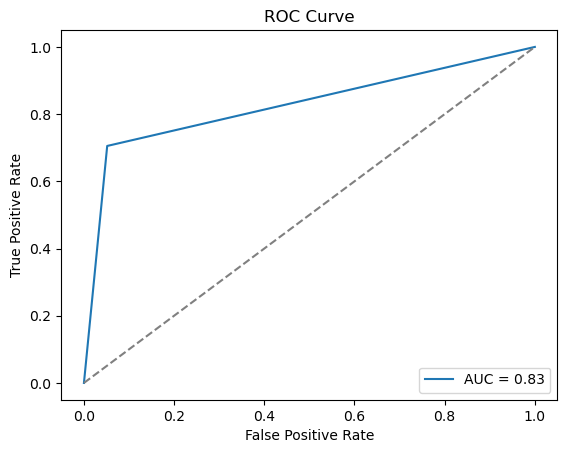

              precision    recall  f1-score   support

           0       0.82      0.95      0.88     10858
           1       0.91      0.71      0.79      7916

    accuracy                           0.85     18774
   macro avg       0.86      0.83      0.84     18774
weighted avg       0.85      0.85      0.84     18774
 False


In [1028]:
matrix = validateAttriuteWithPosition(dataFrame, ['AttackingSkills','BallControl','ShortPassing','Volleys','SkillAttributes','Dribbling','Dribbling.1','MovementSkills','Reactions','Balance','Positioning','Composure','FinishingAbility','CurveAbility','FreeKickAccuracy','Acceleration','SprintSpeed','Shooting'] ,['ST', 'RW','LW','CM','CAM','LM','RM','CDM'])

print(matrix[0], matrix[1])

The model performs well in predicting the False class, but it underperforms in predicting the True class, as seen by the low recall (0.75) and F1-score (0.79) for this class.
The ROC AUC of 0.83 confirms that the model has only good ability to distinguish between True and False instances, and its performance is skewed towards the majority False class.

However due to some intuitive data and because we will retain the best position in our Machine learning model I decided to move forwards and delete these columns 

In [1029]:
dataFrame=dataFrame.drop(columns=['AttackingSkills','BallControl','ShortPassing','Volleys','SkillAttributes','Dribbling','MovementSkills','Reactions','Balance','Positioning','Composure','Dribbling.1','FinishingAbility','CurveAbility','FreeKickAccuracy','Acceleration','SprintSpeed','Shooting','Country'] )

dataFrame.to_csv('modified-data.csv')


In [1030]:


# Sort data by 'PlayerName' and 'index'
data_sorted = dataFrame.sort_values(by=['PlayerName', 'index'], ascending=[True, True])

# Mark the latest record for each player
data_sorted['is_latest'] = data_sorted.groupby('PlayerName')['index'].transform('max') == data_sorted['index']

# Split into latest and historical records
latest_records = data_sorted[data_sorted['is_latest']].drop(columns=['is_latest'])
historical_records = data_sorted[~data_sorted['is_latest']].drop(columns=['is_latest'])

# Save both dataframes to CSV files (optional)
latest_records.to_csv('latest_records.csv', index=False)
historical_records.to_csv('historical_records.csv', index=False)

dataFrame = latest_records

dataFrame=dataFrame.drop(columns=['ContractInfo','PlayerID','PlayerName','FullName','PhotoURL','PlayerURL','PlayingPositions','MarketValue','ReleaseClause','DateJoined','WeeklyWage','BaseStats', 'MarketValue_category_euqal_freq'])

dataFrame.to_csv('final.csv')

## evaluation and optimization

Training set shape: (15232, 781), Validation set shape: (896, 781), Test set shape: (1792, 781)
ROC AUC on Validation Set: 0.90
ROC AUC on Test Set: 0.89


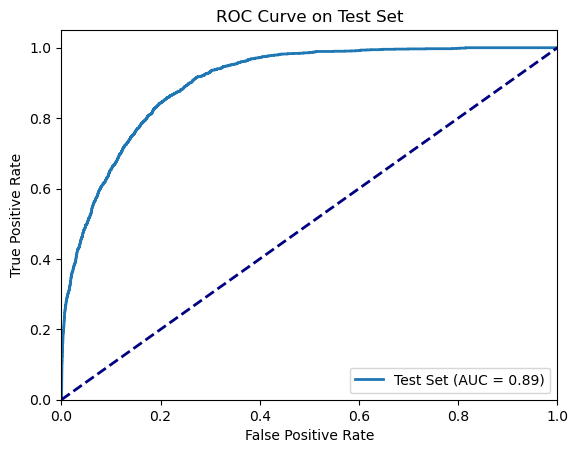

Logistic Regression Coefficients:
   CurrentClub_1. FC Heidenheim 1846  CurrentClub_1. FC Kaiserslautern  \
0                          -0.004876                          0.000578   
1                          -0.008809                         -0.001046   
2                           0.073049                         -0.009677   
3                          -0.000269                         -0.000517   
4                          -0.051020                         -0.010567   
5                           0.024769                         -0.020791   
6                           0.001176                          0.020327   
7                          -0.000013                         -0.000001   
8                           0.037961                          0.048362   
9                          -0.048935                          0.096595   

   CurrentClub_1. FC Köln  CurrentClub_1. FC Magdeburg  \
0               -0.008055                -3.763140e-02   
1               -0.066572          

In [1031]:

# Step 1: Automatically detect categorical and numerical columns
target_column = 'MarketValue_bins' 

# Separate columns into numerical and categorical based on data types
numerical_columns = dataFrame.select_dtypes(include=['number']).columns.tolist()
categorical_columns = dataFrame.select_dtypes(exclude=['number']).columns.tolist()

# Remove the target column from both lists if it's present
if target_column in numerical_columns:
    numerical_columns.remove(target_column)
if target_column in categorical_columns:
    categorical_columns.remove(target_column)

# Step 2: Handle missing values
# For categorical columns, replace NaNs with 'Unknown'
dataFrame[numerical_columns] = dataFrame[numerical_columns].fillna(0)

# For numerical columns, drop rows where NaN is present
dataFrame = dataFrame.dropna(subset=numerical_columns)

# Step 3: Preprocess data (One-hot encode categorical columns)
encoded_data = pd.get_dummies(dataFrame[categorical_columns])

# Step 4: Bin numerical columns into ranges if necessary (optional)
for col in numerical_columns:
    encoded_data[col] = pd.cut(dataFrame[col], bins=5, labels=False)

# Combine one-hot encoded columns and numerical data
processed_data = pd.concat([encoded_data, dataFrame[numerical_columns]], axis=1)

# Step 5: Define the target and split the data
X = processed_data  # Features
y = dataFrame[target_column]  # Target

# First, split data into 90% training+validation and 10% testing
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.10, stratify=y, random_state=42)

# Now, split the 90% training+validation into 85% training and 5% validation
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=(5/90), stratify=y_train_val, random_state=42)

# Check the shapes to confirm split
print(f"Training set shape: {X_train.shape}, Validation set shape: {X_val.shape}, Test set shape: {X_test.shape}")

# Step 6: Train Logistic Regression on the training set
model = LogisticRegression(solver='liblinear', multi_class='ovr', max_iter=200)
model.fit(X_train, y_train)

# Step 7: Evaluate on the validation set
y_val_probs = model.predict_proba(X_val)
y_val_bin = label_binarize(y_val, classes=sorted(y_train.unique()))

# Calculate ROC AUC for validation set
roc_auc_val = roc_auc_score(y_val_bin, y_val_probs, average='macro', multi_class='ovr')
print(f'ROC AUC on Validation Set: {roc_auc_val:.2f}')

# Step 8: Evaluate on the test set
y_test_probs = model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=sorted(y_train.unique()))

# Calculate ROC AUC for test set
roc_auc_test = roc_auc_score(y_test_bin, y_test_probs, average='macro', multi_class='ovr')
print(f'ROC AUC on Test Set: {roc_auc_test:.2f}')

# Step 9: Plot ROC curve for the test set
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_test_probs.ravel())
plt.plot(fpr, tpr, lw=2, label=f'Test Set (AUC = {roc_auc_test:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc="lower right")
plt.show()

# Get the model coefficients
coefficients = model.coef_  # For multi-class, this will be an array
intercept = model.intercept_

# Create a DataFrame to print the coefficients
coef_df = pd.DataFrame(coefficients, columns=X_train.columns)
coef_df['Intercept'] = intercept

print("Logistic Regression Coefficients:")
print(coef_df)



# Group Component 2
--- start ---
## optimal model comparison

Training set shape: (15232, 781), Validation set shape: (896, 781), Test set shape: (1792, 781)
ROC AUC on Validation Set: 0.90
ROC AUC on Test Set: 0.89


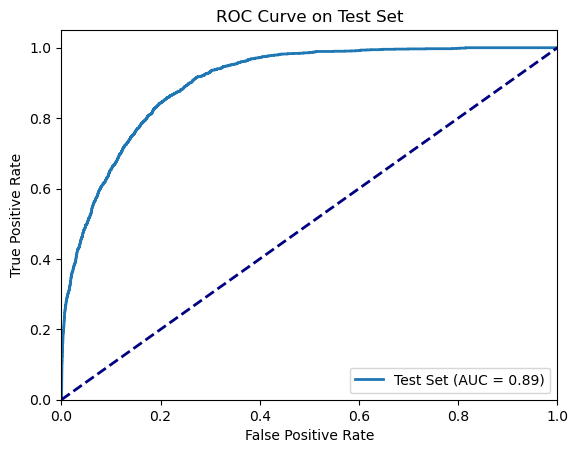

Logistic Regression Coefficients:
   CurrentClub_1. FC Heidenheim 1846  CurrentClub_1. FC Kaiserslautern  \
0                          -0.004876                          0.000578   
1                          -0.008809                         -0.001046   
2                           0.073049                         -0.009677   
3                          -0.000269                         -0.000517   
4                          -0.051020                         -0.010567   
5                           0.024769                         -0.020791   
6                           0.001176                          0.020327   
7                          -0.000013                         -0.000001   
8                           0.037961                          0.048362   
9                          -0.048935                          0.096595   

   CurrentClub_1. FC Köln  CurrentClub_1. FC Magdeburg  \
0               -0.008055                -3.763140e-02   
1               -0.066572          

In [1031]:
# Step 7: Evaluate on the validation set
y_val_probs = model.predict_proba(X_val)
y_val_bin = label_binarize(y_val, classes=sorted(y_train.unique()))

# Calculate ROC AUC for validation set
roc_auc_val = roc_auc_score(y_val_bin, y_val_probs, average='macro', multi_class='ovr')
print(f'ROC AUC on Validation Set: {roc_auc_val:.2f}')

# Step 8: Evaluate on the test set
y_test_probs = model.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=sorted(y_train.unique()))

# Calculate ROC AUC for test set
roc_auc_test = roc_auc_score(y_test_bin, y_test_probs, average='macro', multi_class='ovr')
print(f'ROC AUC on Test Set: {roc_auc_test:.2f}')

# Step 9: Plot ROC curve for the test set
fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_test_probs.ravel())
plt.plot(fpr, tpr, lw=2, label=f'Test Set (AUC = {roc_auc_test:.2f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve on Test Set')
plt.legend(loc="lower right")
plt.show()

# Get the model coefficients
coefficients = model.coef_  # For multi-class, this will be an array
intercept = model.intercept_

# Create a DataFrame to print the coefficients
coef_df = pd.DataFrame(coefficients, columns=X_train.columns)
coef_df['Intercept'] = intercept

print("Logistic Regression Coefficients:")
print(coef_df)



f1:  0.8522168315247555
accuracy:  0.8519494204425712
precision:  0.8528584144803376
recall:  0.8519494204425712
roc_auc:  0.9886625821056635


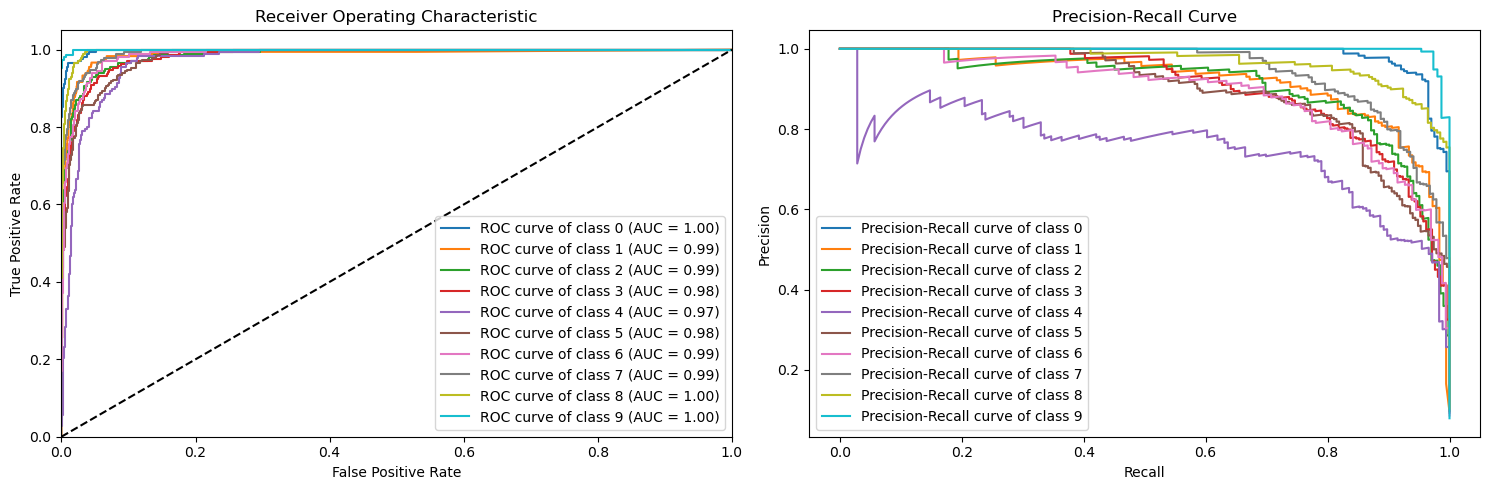

In [34]:
y_pred = bag_clf.predict(X_test)
y_probability = bag_clf.predict_proba(X_test)


f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_probability, multi_class='ovr')

print("f1: ",f1)
print("accuracy: ",accuracy)
print("precision: ",precision)
print("recall: ",recall)
print("roc_auc: ",roc_auc)

# beautiful graph
# ROC curve
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# ROC
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_test, y_probability[:, i], pos_label=i)
    ax[0].plot(fpr, tpr, label=f'ROC curve of class {i} (AUC = {roc_auc_score(y_test == i, y_probability[:, i]):.2f})')

ax[0].plot([0, 1], [0, 1], 'k--')
ax[0].set_xlim([0.0, 1.0])
ax[0].set_ylim([0.0, 1.05])
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].set_title('Receiver Operating Characteristic')
ax[0].legend(loc="lower right")

# Precision-Recall
for i in range(len(np.unique(y))):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_probability[:, i], pos_label=i)
    ax[1].plot(recall_vals, precision_vals, label=f'Precision-Recall curve of class {i}')

ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall Curve')
ax[1].legend(loc="lower left")

# show
plt.tight_layout()
plt.show()

Final Results on Test Set:
Final Accuracy: 0.8751
Final F1 Score: 0.8750
Final Recall: 0.8751
Final Precision: 0.8753
Final ROC AUC Score: 0.9927


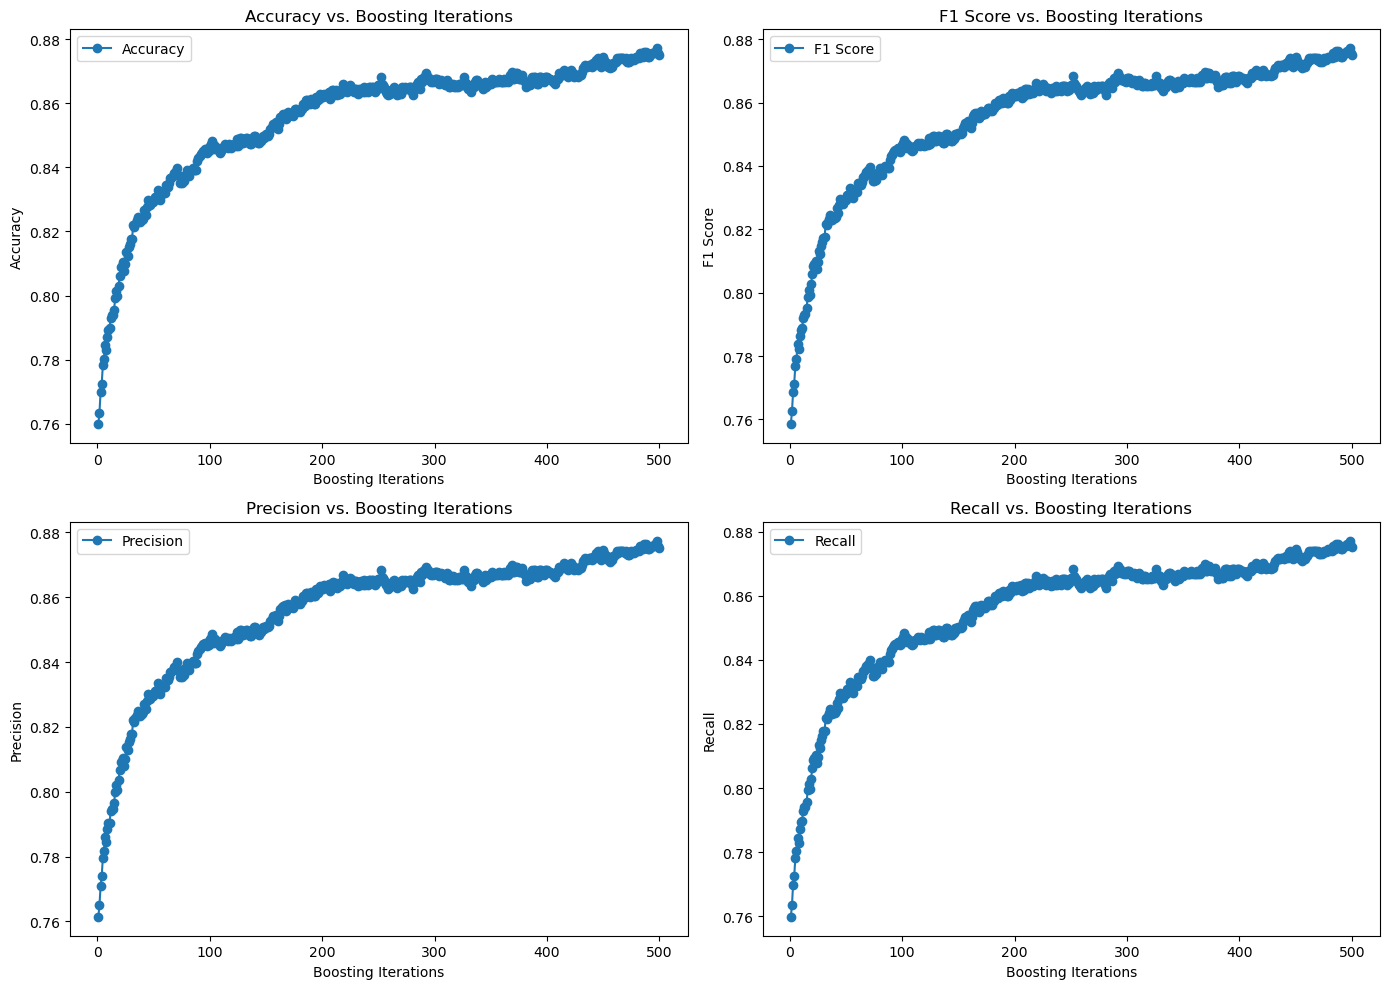

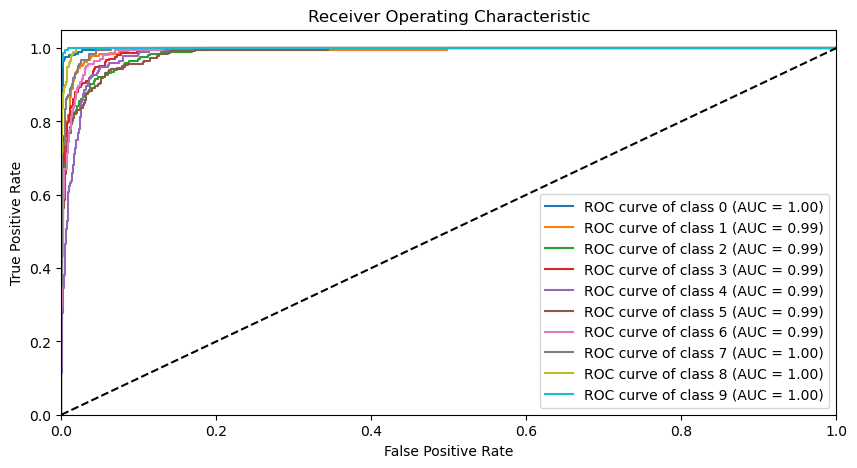

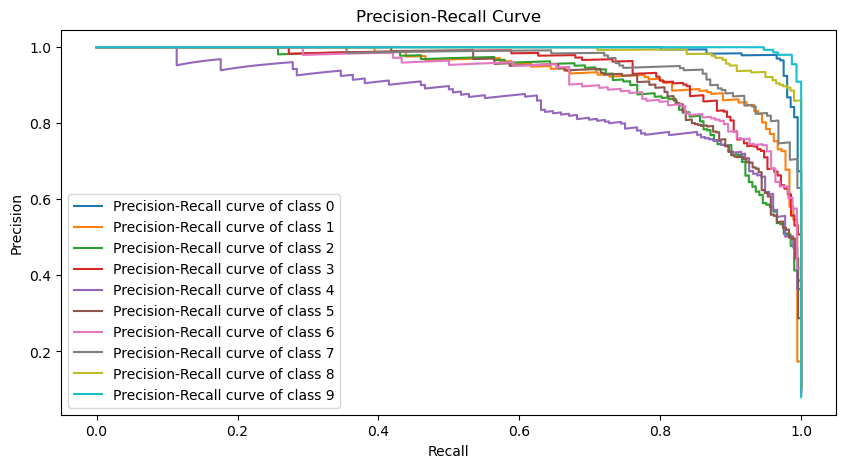

In [16]:
acc_list = []
f1_list = []
recall_list = []
precision_list = []
roc_auc_list = []


for y_pred_staged, y_proba_staged in zip(gb.staged_predict(X_tests), gb.staged_predict_proba(X_tests)):
    acc_list.append(accuracy_score(y_tests, y_pred_staged))
    f1_list.append(f1_score(y_tests, y_pred_staged, average='weighted'))
    recall_list.append(recall_score(y_tests, y_pred_staged, average='weighted'))
    precision_list.append(precision_score(y_tests, y_pred_staged, average='weighted'))
    roc_auc_list.append(roc_auc_score(y_tests, y_proba_staged, multi_class='ovr'))


y_pred_final = gb.predict(X_tests)
y_proba_final = gb.predict_proba(X_tests)


final_acc = accuracy_score(y_tests, y_pred_final)
final_f1 = f1_score(y_tests, y_pred_final, average='weighted')
final_recall = recall_score(y_tests, y_pred_final, average='weighted')
final_precision = precision_score(y_tests, y_pred_final, average='weighted')
final_roc_auc = roc_auc_score(y_tests, y_proba_final, multi_class='ovr')


print("Final Results on Test Set:")
print(f"Final Accuracy: {final_acc:.4f}")
print(f"Final F1 Score: {final_f1:.4f}")
print(f"Final Recall: {final_recall:.4f}")
print(f"Final Precision: {final_precision:.4f}")
print(f"Final ROC AUC Score: {final_roc_auc:.4f}")


plt.figure(figsize=(14, 10))


plt.subplot(2, 2, 1)
plt.plot(range(1, len(acc_list) + 1), acc_list, label='Accuracy', marker='o')
plt.title('Accuracy vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(2, 2, 2)
plt.plot(range(1, len(f1_list) + 1), f1_list, label='F1 Score', marker='o')
plt.title('F1 Score vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('F1 Score')
plt.legend()


plt.subplot(2, 2, 3)
plt.plot(range(1, len(precision_list) + 1), precision_list, label='Precision', marker='o')
plt.title('Precision vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('Precision')
plt.legend()


plt.subplot(2, 2, 4)
plt.plot(range(1, len(recall_list) + 1), recall_list, label='Recall', marker='o')
plt.title('Recall vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_tests, y_proba_final[:, i], pos_label=i)
    plt.plot(fpr, tpr, label=f'ROC curve of class {i} (AUC = {roc_auc_score(y_tests == i, y_proba_final[:, i]):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


plt.figure(figsize=(10, 5))
for i in range(len(np.unique(y))):
    precision_vals, recall_vals, _ = precision_recall_curve(y_tests, y_proba_final[:, i], pos_label=i)
    plt.plot(recall_vals, precision_vals, label=f'Precision-Recall curve of class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()

## recommendation
we decided that the RF is the best model for its near prefect roc-auc score and highest performance

Final Results on Test Set:
Final Accuracy: 0.8751
Final F1 Score: 0.8750
Final Recall: 0.8751
Final Precision: 0.8753
Final ROC AUC Score: 0.9927


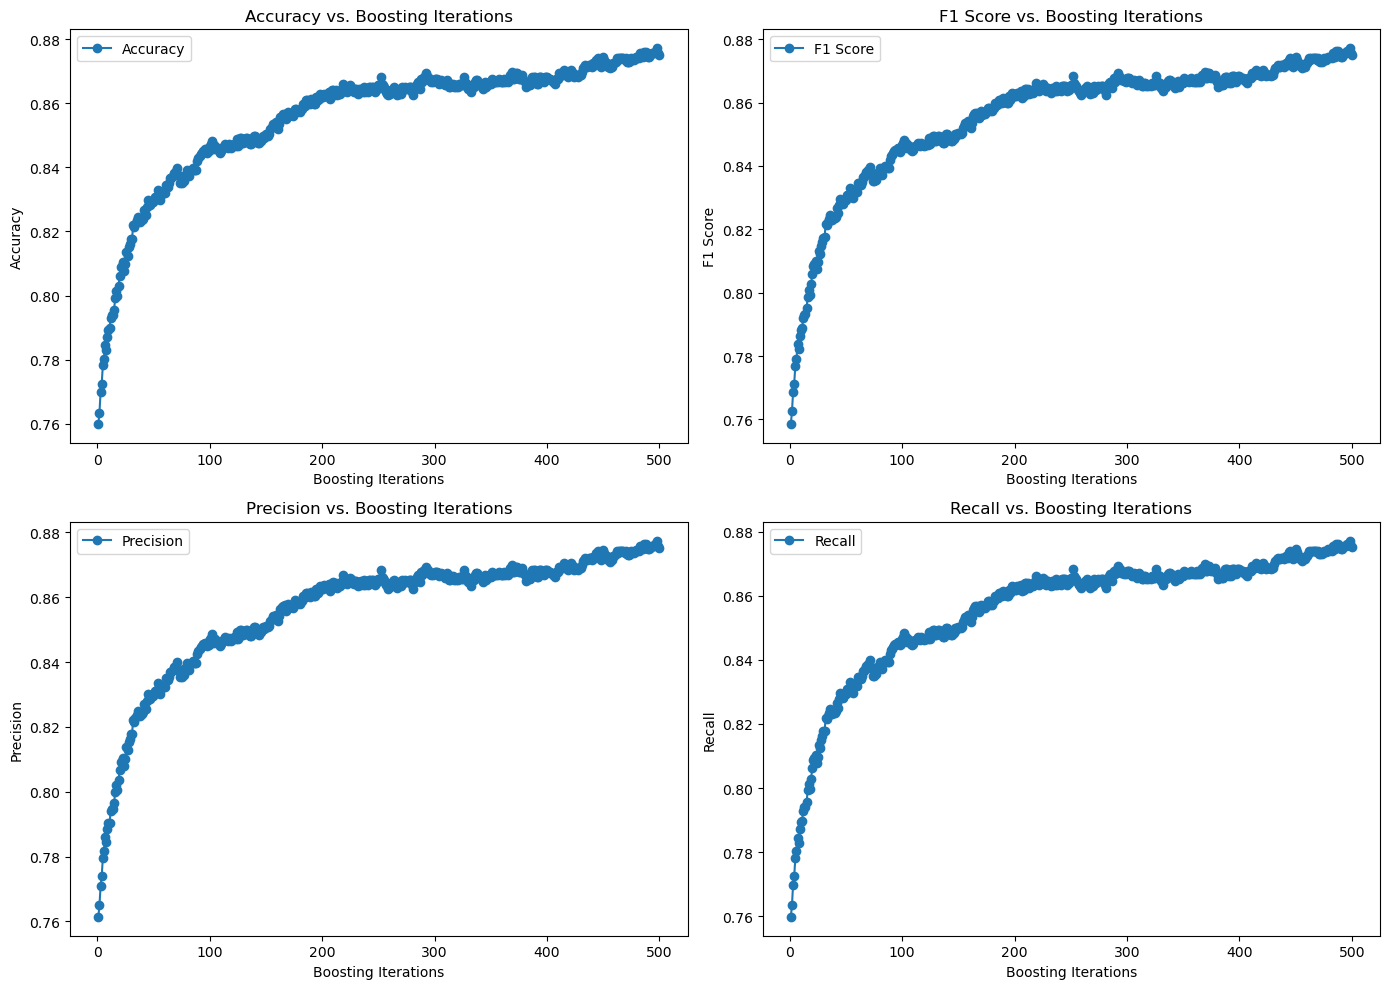

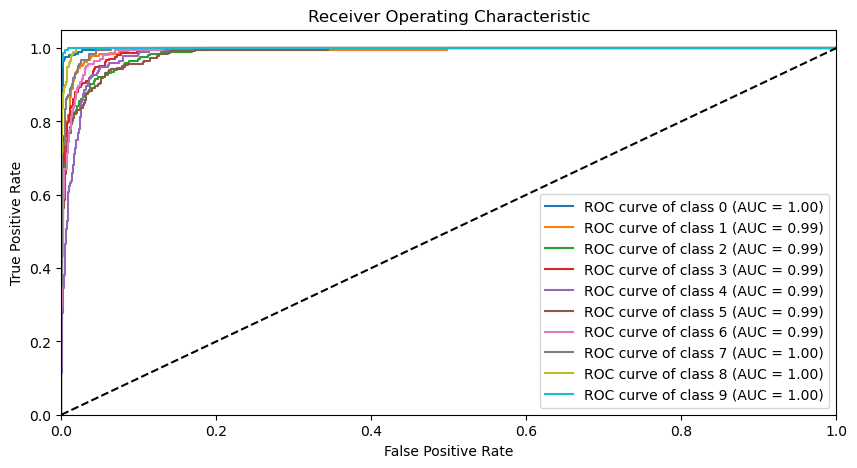

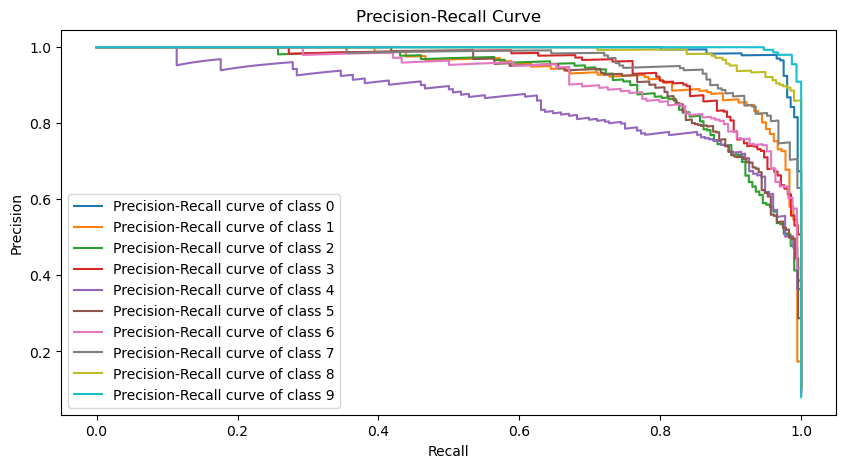

In [16]:
X = df.drop('target', axis=1)
y = df['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


base_rf = RandomForestClassifier(n_estimators=50,max_depth=None,min_samples_leaf=1,min_samples_split=2, random_state=42)


gb = GradientBoostingClassifier(init=base_rf, n_estimators=500, learning_rate=0.1, max_depth=3, random_state=42)


gb.fit(X_train, y_train)


acc_list = []
f1_list = []
recall_list = []
precision_list = []
roc_auc_list = []


for y_pred_staged, y_proba_staged in zip(gb.staged_predict(X_test), gb.staged_predict_proba(X_test)):
    acc_list.append(accuracy_score(y_test, y_pred_staged))
    f1_list.append(f1_score(y_test, y_pred_staged, average='weighted'))
    recall_list.append(recall_score(y_test, y_pred_staged, average='weighted'))
    precision_list.append(precision_score(y_test, y_pred_staged, average='weighted'))
    roc_auc_list.append(roc_auc_score(y_test, y_proba_staged, multi_class='ovr'))


y_pred_final = gb.predict(X_test)
y_proba_final = gb.predict_proba(X_test)


final_acc = accuracy_score(y_test, y_pred_final)
final_f1 = f1_score(y_test, y_pred_final, average='weighted')
final_recall = recall_score(y_test, y_pred_final, average='weighted')
final_precision = precision_score(y_test, y_pred_final, average='weighted')
final_roc_auc = roc_auc_score(y_test, y_proba_final, multi_class='ovr')


print("Final Results on Test Set:")
print(f"Final Accuracy: {final_acc:.4f}")
print(f"Final F1 Score: {final_f1:.4f}")
print(f"Final Recall: {final_recall:.4f}")
print(f"Final Precision: {final_precision:.4f}")
print(f"Final ROC AUC Score: {final_roc_auc:.4f}")


plt.figure(figsize=(14, 10))


plt.subplot(2, 2, 1)
plt.plot(range(1, len(acc_list) + 1), acc_list, label='Accuracy', marker='o')
plt.title('Accuracy vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(2, 2, 2)
plt.plot(range(1, len(f1_list) + 1), f1_list, label='F1 Score', marker='o')
plt.title('F1 Score vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('F1 Score')
plt.legend()


plt.subplot(2, 2, 3)
plt.plot(range(1, len(precision_list) + 1), precision_list, label='Precision', marker='o')
plt.title('Precision vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('Precision')
plt.legend()


plt.subplot(2, 2, 4)
plt.plot(range(1, len(recall_list) + 1), recall_list, label='Recall', marker='o')
plt.title('Recall vs. Boosting Iterations')
plt.xlabel('Boosting Iterations')
plt.ylabel('Recall')
plt.legend()

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 5))
for i in range(len(np.unique(y))):
    fpr, tpr, _ = roc_curve(y_test, y_proba_final[:, i], pos_label=i)
    plt.plot(fpr, tpr, label=f'ROC curve of class {i} (AUC = {roc_auc_score(y_test == i, y_proba_final[:, i]):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


plt.figure(figsize=(10, 5))
for i in range(len(np.unique(y))):
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba_final[:, i], pos_label=i)
    plt.plot(recall_vals, precision_vals, label=f'Precision-Recall curve of class {i}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc="lower left")
plt.show()